## Visualize effects
Notebook with visualizations used for the SASHIMI submission.

In [1]:
from copy import deepcopy
from pathlib import Path

import ants
import numpy as np

from synthfcd.core.deformations import abnormal_gyration, cortical_thickening
from synthfcd.core.diffusion import boundary_blurring, hyperintensity
from synthfcd.core.grow_lesion import grow_random_lesion
from synthfcd.core.masks import SynthSegLabel
from synthfcd.core.texture import texture_restoration
from synthfcd.core.utils import bbox_from_mask, generate_application_field, warp
from synthfcd.visualize import (
    overlay_intensity_field,
    overlay_mask_outline,
    overlay_vector_field_2d,
    overlay_vector_field_on_intensity_3d,
    plot_npy_label_intensity_3d,
    plot_npy_label_slices,
    plot_npy_volumes,
    show_plot_handles,
)

# Example data; replace with your own data
data_dir = "~/Downloads/example_data"
flair_path = f"{data_dir}/sub-039_ses-01_FLAIR.nii.gz"
t1_path = f"{data_dir}/sub-039_ses-01_T1w.nii.gz"
seg_path = f"{data_dir}/sub-039_ses-01_synthseg.nii.gz"

# Load images
flair = ants.image_read(flair_path)
flair_arr = flair.numpy()

t1 = ants.image_read(t1_path)
t1 = ants.decrop_image(t1, flair) # align to image
t1_arr = t1.numpy()

# Load masks
seg_mask = ants.image_read(seg_path)
seg_mask = ants.decrop_image(seg_mask, flair) # align to image
seg_mask_arr = seg_mask.numpy().astype(np.int32) 

# Get spacing
spacing = t1.spacing  # data is co-registered and resampled

#### 1. Lesion growth

{'volume': 302.0, 'hemisphere': 'left', 'DKT_labels': ['Left Paracentral', 'Left Posterior Cingulate']}


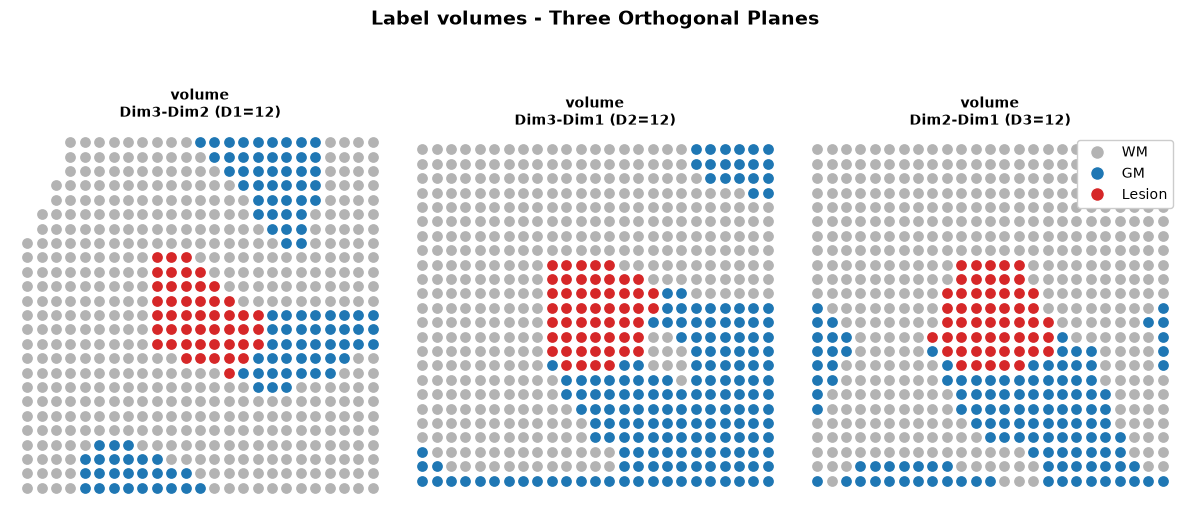

In [32]:
same_as_growth_fig = False

result = grow_random_lesion(
    seg_mask_arr,
    volume=300,
    gm_prob=0.8,
    spacing=t1.spacing,
    growth="distance",
    lobe=SynthSegLabel.get_frontal_lobe_labels(),
    bottom_of_sulcus=True,
    fast_mode=True,
    random_seed=30,
    distance_noise_ratio=0.3
)
lesion_mask = result["target"].copy()

print(result["growth_stats"])

if same_as_growth_fig:
    # Computed by running growth with above settings for volume=30, pad=10
    fixed_bbox = (
        slice(np.int64(106), np.int64(129), None), 
        slice(np.int64(118), np.int64(141), None), 
        slice(np.int64(62), np.int64(85), None)
    )
    marker_size = 100
else:
    fixed_bbox = bbox_from_mask(lesion_mask, pad=8)
    marker_size = 60

# Add lesion mask to seg_mask_arr
seg_w_lesion = seg_mask_arr[fixed_bbox].copy()
seg_w_lesion[lesion_mask[fixed_bbox]] = 3000
plot_npy_label_slices(
    label_volume=seg_w_lesion,
    labels=[
        (SynthSegLabel.get_white_matter_labels(), ("WM", "0.7")),
        (SynthSegLabel.get_cortical_labels(), ("GM", "tab:blue")),
        (3000, ("Lesion", "tab:red")),
    ],
    marker_size=marker_size,
    figsize=(12, 6),
    show_axes=False,
    show_legend=True,
)

#### 2. Cortical thickening
Uses same lesion mask and bbox.

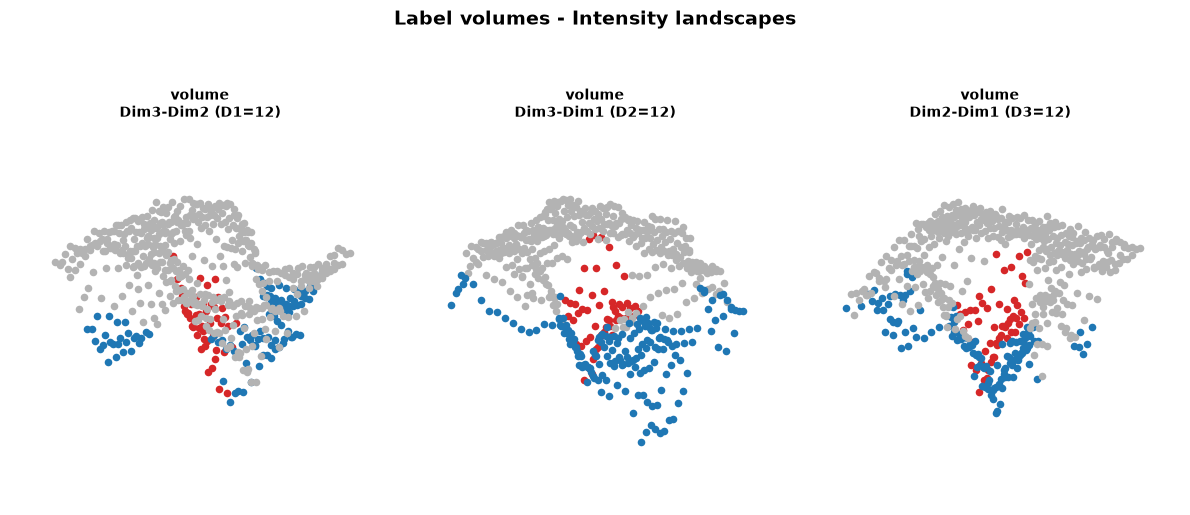

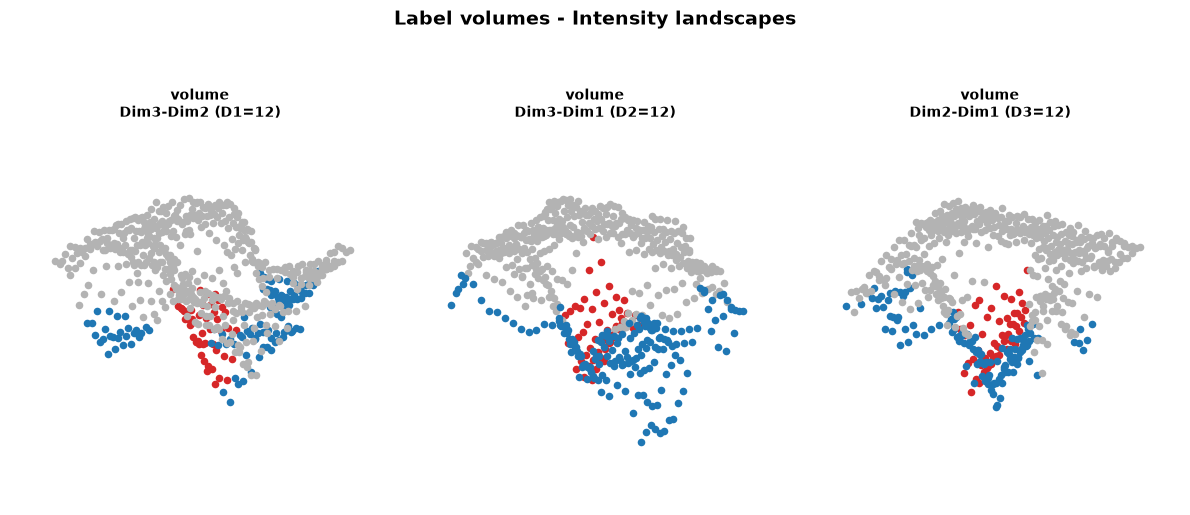

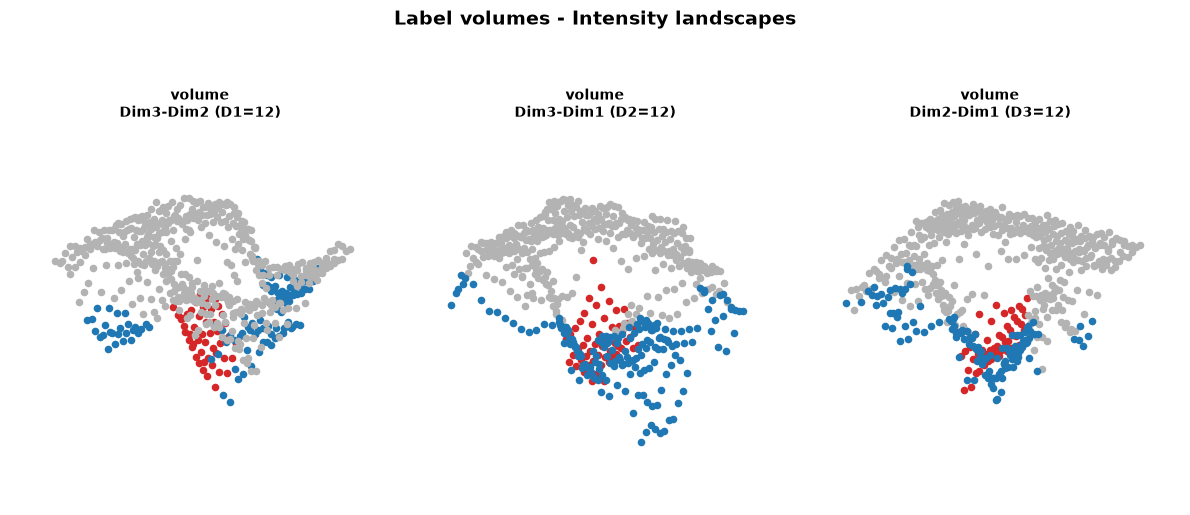

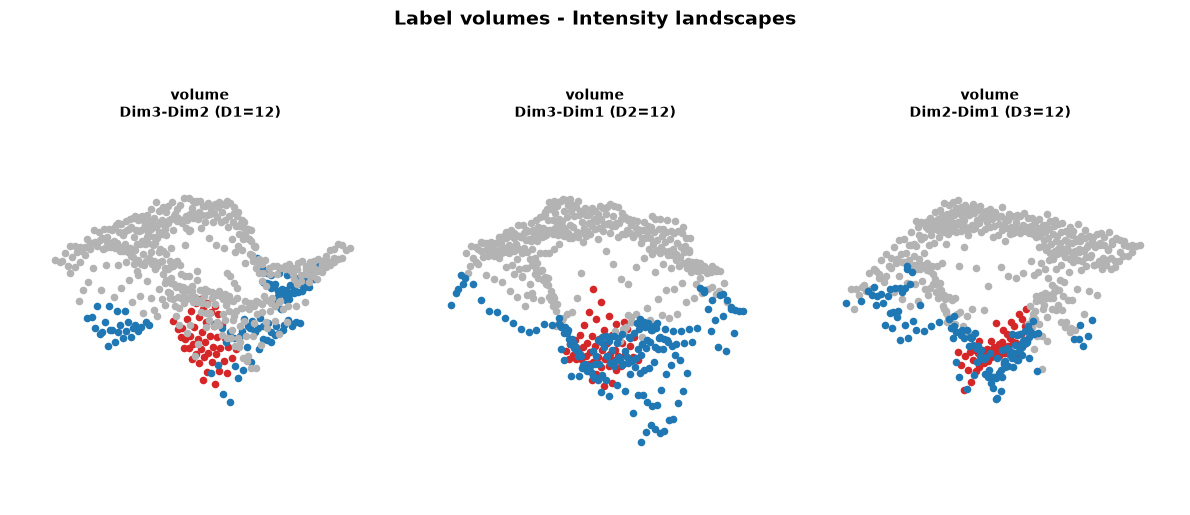

In [31]:
from synthfcd.core.utils import warp_image

# Global settings
img = t1
img_arr = img.numpy()
spacing = img.spacing
app_rolloff = 2.0
n_iters = 3
marker_size = 30
figsize = (12, 6)
elev = 25
overlay_lesion = True
overlay_displacement = False
warp_labels = False
show_grid = False
show_axes = False
show_legend = False

# Initialize shared output
shared_state = {
    "image": img_arr.copy()[fixed_bbox],
    "seg_mask": seg_mask_arr.copy()[fixed_bbox],
    "lesion_mask": lesion_mask.copy()[fixed_bbox],
}
labels: list[tuple[set[int] | int, tuple[str, str]]] = [
    (SynthSegLabel.get_cortical_labels(), ("GM", "tab:blue")),
    (SynthSegLabel.get_white_matter_labels(), ("WM", "0.7")),
]
if overlay_lesion:
    labels.append((3000, ("Lesion", "tab:red")))

# Plot before; also keep handles for overlaying field prior to deformation
seg_mask_w_lesion = shared_state['seg_mask'].copy()
seg_mask_w_lesion[shared_state['lesion_mask']] = 3000
handles = plot_npy_label_intensity_3d(
    shared_state['image'],
    seg_mask_w_lesion if overlay_lesion else shared_state['seg_mask'],
    labels=labels,
    figsize=figsize,
    marker_size=marker_size,
    show_grid=show_grid,
    show_axes=show_axes,
    return_handles=True,
    show=False,
    show_legend=show_legend,
    elev=elev,
)
shared_state['plot_handles'] = handles

# Iteratively expand cortex
for _ in range(n_iters):
    out = cortical_thickening(
        shared_state['image'].copy(),
        shared_state['seg_mask'].copy(),
        spacing=spacing,
        n_iters=1,
        mm_per_iter=1,
        pial_lower_bound=2.0,
        gwb_upper_bound=3.0,
        edge_rolloff=1.0,
        smooth_sigma=1.0,
    )

    # Constrain displacement field to lesion
    if len(out["effect_field"]) != 1:
        raise ValueError("Expected single effect field")
    ux, uy, uz = out["effect_field"][0]
    local_ux = ux * generate_application_field(
        shared_state['lesion_mask'],
        spacing=spacing,
        rolloff_mm=app_rolloff
    )
    local_uy = uy * generate_application_field(
        shared_state['lesion_mask'],
        spacing=spacing,
        rolloff_mm=app_rolloff
    )
    local_uz = uz * generate_application_field(
        shared_state['lesion_mask'],
        spacing=spacing,
        rolloff_mm=app_rolloff
    )
    local_effect_field = (local_ux, local_uy, local_uz)

    # Apply locally to image, seg_mask, and lesion_mask
    shared_state['image'] = warp_image(
        shared_state['image'],
        local_effect_field,
        interp_order=3,
    )
    if warp_labels:
        shared_state['seg_mask'] = warp_image(
            shared_state['seg_mask'],
            local_effect_field,
            interp_order=0,
        )
        shared_state['lesion_mask'] |= warp_image(
            shared_state['lesion_mask'],
            local_effect_field,
            interp_order=0,
        )
    
    # Plot and update handles
    out_seg_w_lesion = shared_state['seg_mask'].copy()
    out_seg_w_lesion[shared_state['lesion_mask']] = 3000
    shared_state['plot_handles'] = plot_npy_label_intensity_3d(
        shared_state['image'],
        out_seg_w_lesion if overlay_lesion else shared_state['seg_mask'],
        labels=labels,
        figsize=figsize,
        marker_size=marker_size,
        show_grid=show_grid,
        show_axes=show_axes,
        return_handles=True,
        show=False,
        show_legend=show_legend,
        elev=elev,
    )
    # Plot local deformation field
    if overlay_displacement:
        overlay_vector_field_on_intensity_3d(
            handles=shared_state['plot_handles'],
            vector_field=local_effect_field,
            stride=1,
            arrow_scale=1,
            length=2,
            colors="k",
            linewidths=1,
            arrow_length_ratio=0.3,
            pivot="tail",
        )
    show_plot_handles(handles)

cortical_thickening_outs = deepcopy(shared_state)

#### 3. GM-WM boundary blurring
Uses same image, segmentation mask, lesion mask and bbox.

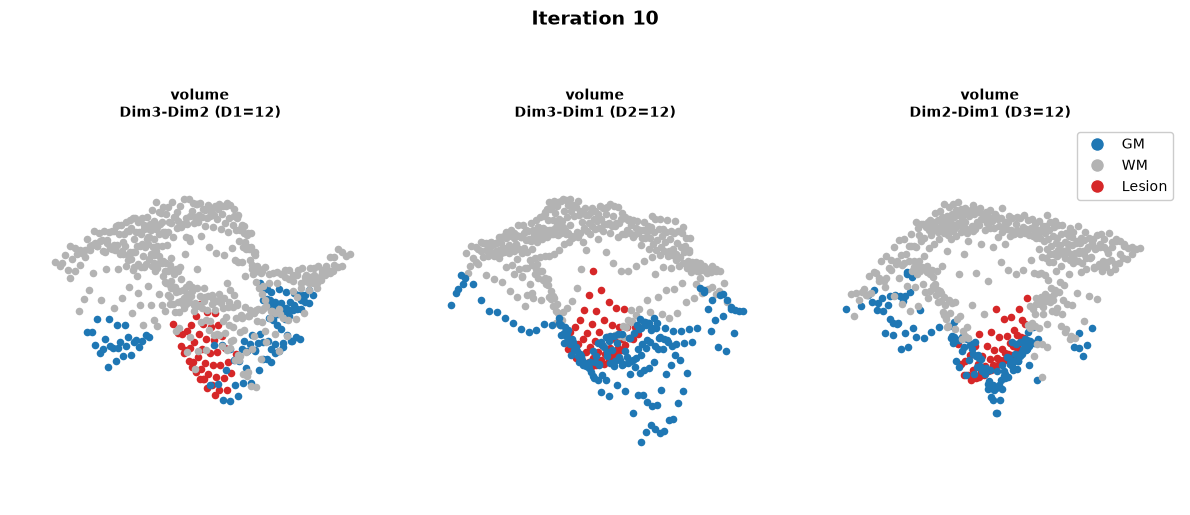

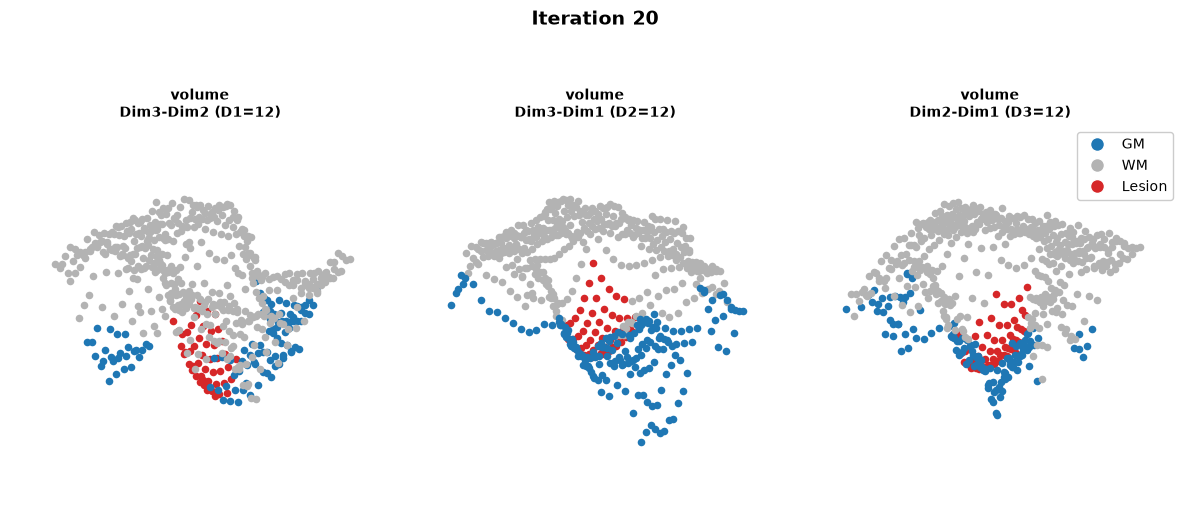

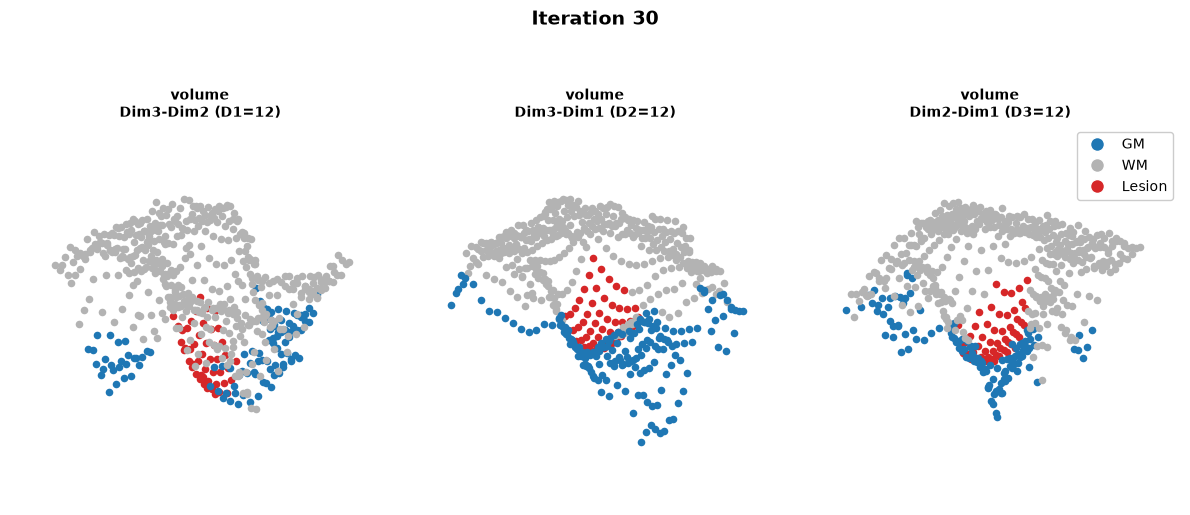

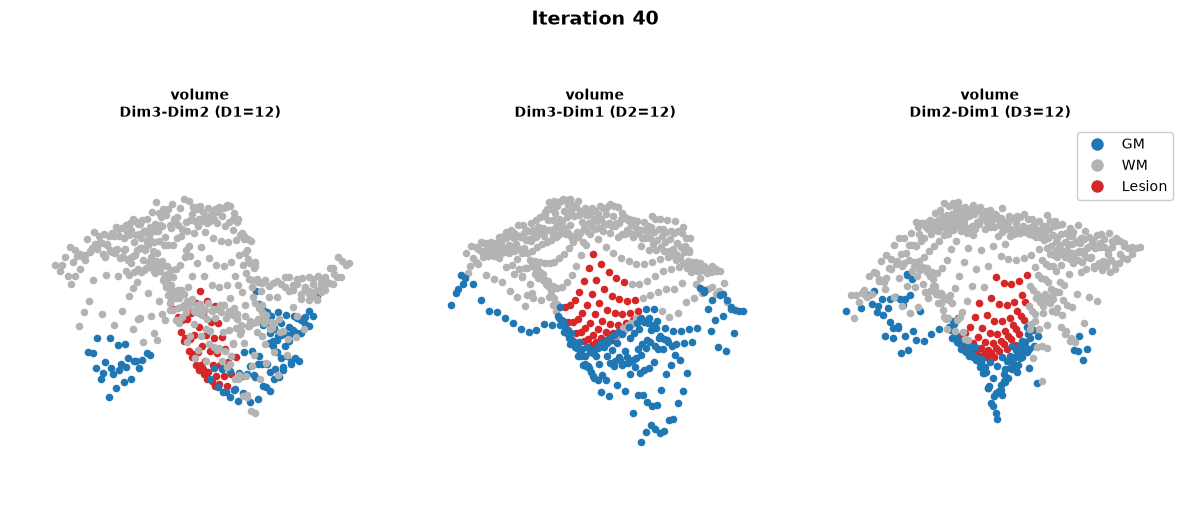

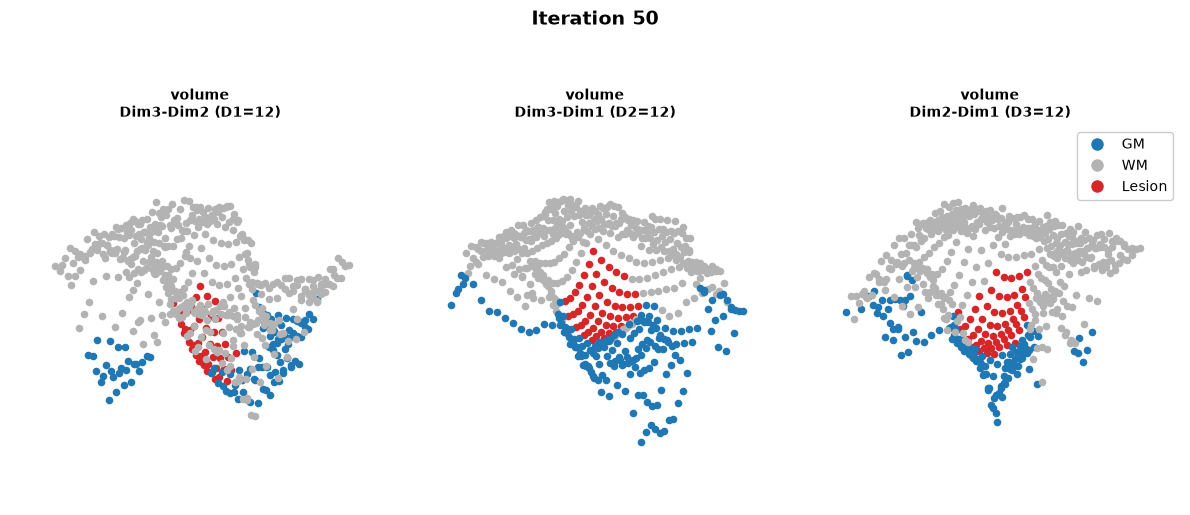

In [ ]:

# Global settings
app_rolloff = 3.0
n_iters = 50
marker_size = 30
figsize = (12, 6)
elev = 25
overlay_lesion = True
show_grid = True
show_axes = False
show_legend = True

# Initialize shared output
shared_state = {
    "image": cortical_thickening_outs["image"],
    "seg_mask": cortical_thickening_outs["seg_mask"],
    "lesion_mask": cortical_thickening_outs["lesion_mask"],
}
labels = [
    (SynthSegLabel.get_cortical_labels(), ("GM", "tab:blue")),
    (SynthSegLabel.get_white_matter_labels(), ("WM", "0.7")),
]
if overlay_lesion:
    labels.append((3000, ("Lesion", "tab:red")))


# Iteratively expand cortex
for i in range(n_iters):
    out = boundary_blurring(
        shared_state['image'].copy(),
        shared_state['seg_mask'].copy(),
        spacing=spacing,
        n_iters=1,
        pial_lower_bound=2.0,
        gwb_upper_bound=3.0,
        edge_rolloff=1.0,
        kappa=0.95
    )

    # Constrain displacement field to lesion
    local_effect_field = out["effect_field"] * generate_application_field(
        shared_state['lesion_mask'],
        spacing=spacing,
        rolloff_mm=app_rolloff
    )

    # Apply locally to image
    shared_state['image'] = shared_state['image'] + local_effect_field

    # Plot and update handles
    if (i + 1) % (n_iters // 5) == 0:
        out_seg_w_lesion = shared_state['seg_mask'].copy()
        out_seg_w_lesion[shared_state['lesion_mask']] = 3000
        labels: list[tuple[set[int] | int, tuple[str, str]]] = [
            (SynthSegLabel.get_cortical_labels(), ("GM", "tab:blue")),
            (SynthSegLabel.get_white_matter_labels(), ("WM", "0.7")),
        ]
        if overlay_lesion:
            labels.append((3000, ("Lesion", "tab:red")))
        shared_state['plot_handles'] = plot_npy_label_intensity_3d(
            shared_state['image'],
            out_seg_w_lesion if overlay_lesion else shared_state['seg_mask'],
            labels=labels,
            title=f"Iteration {i+1}",
            figsize=figsize,
            marker_size=marker_size,
            show_grid=show_grid,
            show_axes=show_axes,
            return_handles=True,
            show=False,
            show_legend=show_legend,
            elev=elev,
        )
    show_plot_handles(handles)

#### 4. Example synthetic lesions

In [34]:
# Helpers
from typing import Any

from synthfcd.pipelines import simple_fcd_simulator
from synthfcd.presets.simple_fcd import draw_simple_fcd_params
from synthfcd.visualize.overlay_mask import overlay_mask_outline


def load_and_simulate(
    t1_path: str,
    flair_path: str,
    seg_path: str,
    presets: str = "default",
    fcd_type: str | None = None,
    custom_params: dict[str, Any] | None = None,
    random_seed: int | None = None,
    *,
    show_params: bool = False,
) -> dict[str, np.ndarray]:
    # Prepare
    t1 = ants.image_read(t1_path, reorient="RAS") # type: ignore
    flair = ants.image_read(flair_path, reorient="RAS") # type: ignore
    seg = ants.image_read(seg_path, reorient="RAS") # type: ignore
    t1_arr = t1.numpy()
    t1_spacing = t1.spacing
    flair_arr = flair.numpy()
    flair_spacing = flair.spacing
    seg_arr = seg.numpy().astype(np.uint32)
    seg_spacing = seg.spacing

    # Check matching
    if t1_spacing != seg_spacing or t1_spacing != flair_spacing:
        raise ValueError("T1, seg, and flair must have the same spacing")
    if t1_arr.shape != seg_arr.shape or t1_arr.shape != flair_arr.shape:
        raise ValueError("T1, seg, and flair must have the same shape")

    # Draw parameters
    if not custom_params:
        params = draw_simple_fcd_params(
            sequences=["T1like", "T2like"],
            presets=presets,
            random_seed=random_seed,
            fcd_type=fcd_type, # type: ignore
        )
    else:
        params = custom_params
    if show_params:
        print(params)
    
    # Run simulation
    out = simple_fcd_simulator(
        images=[t1_arr, flair_arr],
        seg_mask=seg_arr,
        spacing=t1_spacing,
        growth_params=params["growth_params"],
        deformation_params=params["deformation_params"],
        intensity_params=params["intensity_params"],
    )
        
    return {
        "inp_t1": t1_arr,
        "inp_flair": flair_arr,
        "inp_seg": seg_arr,
        "inp_lesion": out["extras"]["orig_target"],
        "out_t1": out["out_images"][0],
        "out_flair": out["out_images"][1],
        "out_lesion": out["extras"]["out_target"],
        "out_seg": out["out_seg_mask"],
    }

# Find paths from dir
def find_path_from_suffix(suffix: str, data_dir: Path) -> Path:
    matches = sorted(
        p for p in data_dir.iterdir() if p.is_file() and p.name.endswith(suffix)
    )
    if len(matches) == 0:
        raise ValueError(
            f"Expected at least one file ending with {suffix!r} in {data_dir}, "
            f"found {len(matches)}: {[p.name for p in matches]}"
        )
    if len(matches) > 1:
        raise ValueError(
            f"Expected at most one file ending with {suffix!r} in {data_dir}, "
            f"found {len(matches)}: {[p.name for p in matches]}"
        )
    return matches[0]

# plot bbox
def plot_bbox(
    out_dict: dict[str, np.ndarray],
    pad_size: int = 10,
    mask_dilation: int = 1,
    figsize: tuple[int, int] = (12, 6),
    ensure_square: bool = True,
):
    bbox = bbox_from_mask(
        out_dict["out_lesion"],
        pad=pad_size,
        ensure_square=ensure_square,
    )
    handles = plot_npy_volumes(
        {
            "orig_t1": out_dict["inp_t1"][bbox],
            "orig_flair": out_dict["inp_flair"][bbox],
            "synth_t1": out_dict["out_t1"][bbox],
            "synth_flair": out_dict["out_flair"][bbox],
        },
        figsize=figsize,
        return_handles=True,
        show=False,
    )
    # Get lesion mask boundary before and after deformations
    lesion_mask_in = out_dict["inp_lesion"][bbox]
    overlay_mask_outline(
        handles,
        lesion_mask_in,
        rows=["orig_t1", "orig_flair"],
        color="tab:red",
        thickness=mask_dilation,
        outwards=True,
        alpha=0.75,
    )
    lesion_mask_out = out_dict["out_lesion"][bbox]
    overlay_mask_outline(
        handles,
        lesion_mask_out,
        rows=["synth_t1", "synth_flair"],
        color="tab:red",
        thickness=mask_dilation,
        outwards=True,
        alpha=0.75,
    )
    show_plot_handles(handles)

running_rng = np.random.RandomState()

##### 4.1 Automatic parametrization

Seed: 536586
{'FCD_type': 'FCD_type_IIb', 'growth_params': {'volume': 3465.4656080363025, 'gm_prob': 0.7518769829016091, 'growth': 'distance', 'lobe': {1024, 1026, 1027, 1028, 2002, 2003, 2012, 2014, 2017, 2018, 2019, 2020, 2024, 1002, 1003, 2026, 2027, 2028, 1012, 1014, 1017, 1018, 1019, 1020}, 'bottom_of_sulcus': False, 'random_seed': 2769931284}, 'deformation_params': {'abnormal_gyration': {'enable': True, 'n_iters': 1, 'mm_per_iter': 0.5243583292691174, 'pial_lower_bound': -2.7334238606863708, 'gwb_upper_bound': 2.97856388616648, 'edge_rolloff': 1.5721813330791718, 'corr_sigma': 13.261768986504697, 'scaling_and_squaring_steps': 5, 'app_field_type': 'outward', 'app_rolloff': 3.062532223249559, 'bbox_thres': 0.01, 'random_seed': 3970508514}, 'cortical_thickening': {'enable': True, 'n_iters': 1, 'mm_per_iter': 0.6632822660017146, 'pial_lower_bound': 1.7971462958123887, 'gwb_lower_bound': -2.7091440327341623, 'gwb_upper_bound': 2.142117611297353, 'edge_rolloff': 1.236384050007747, 'app

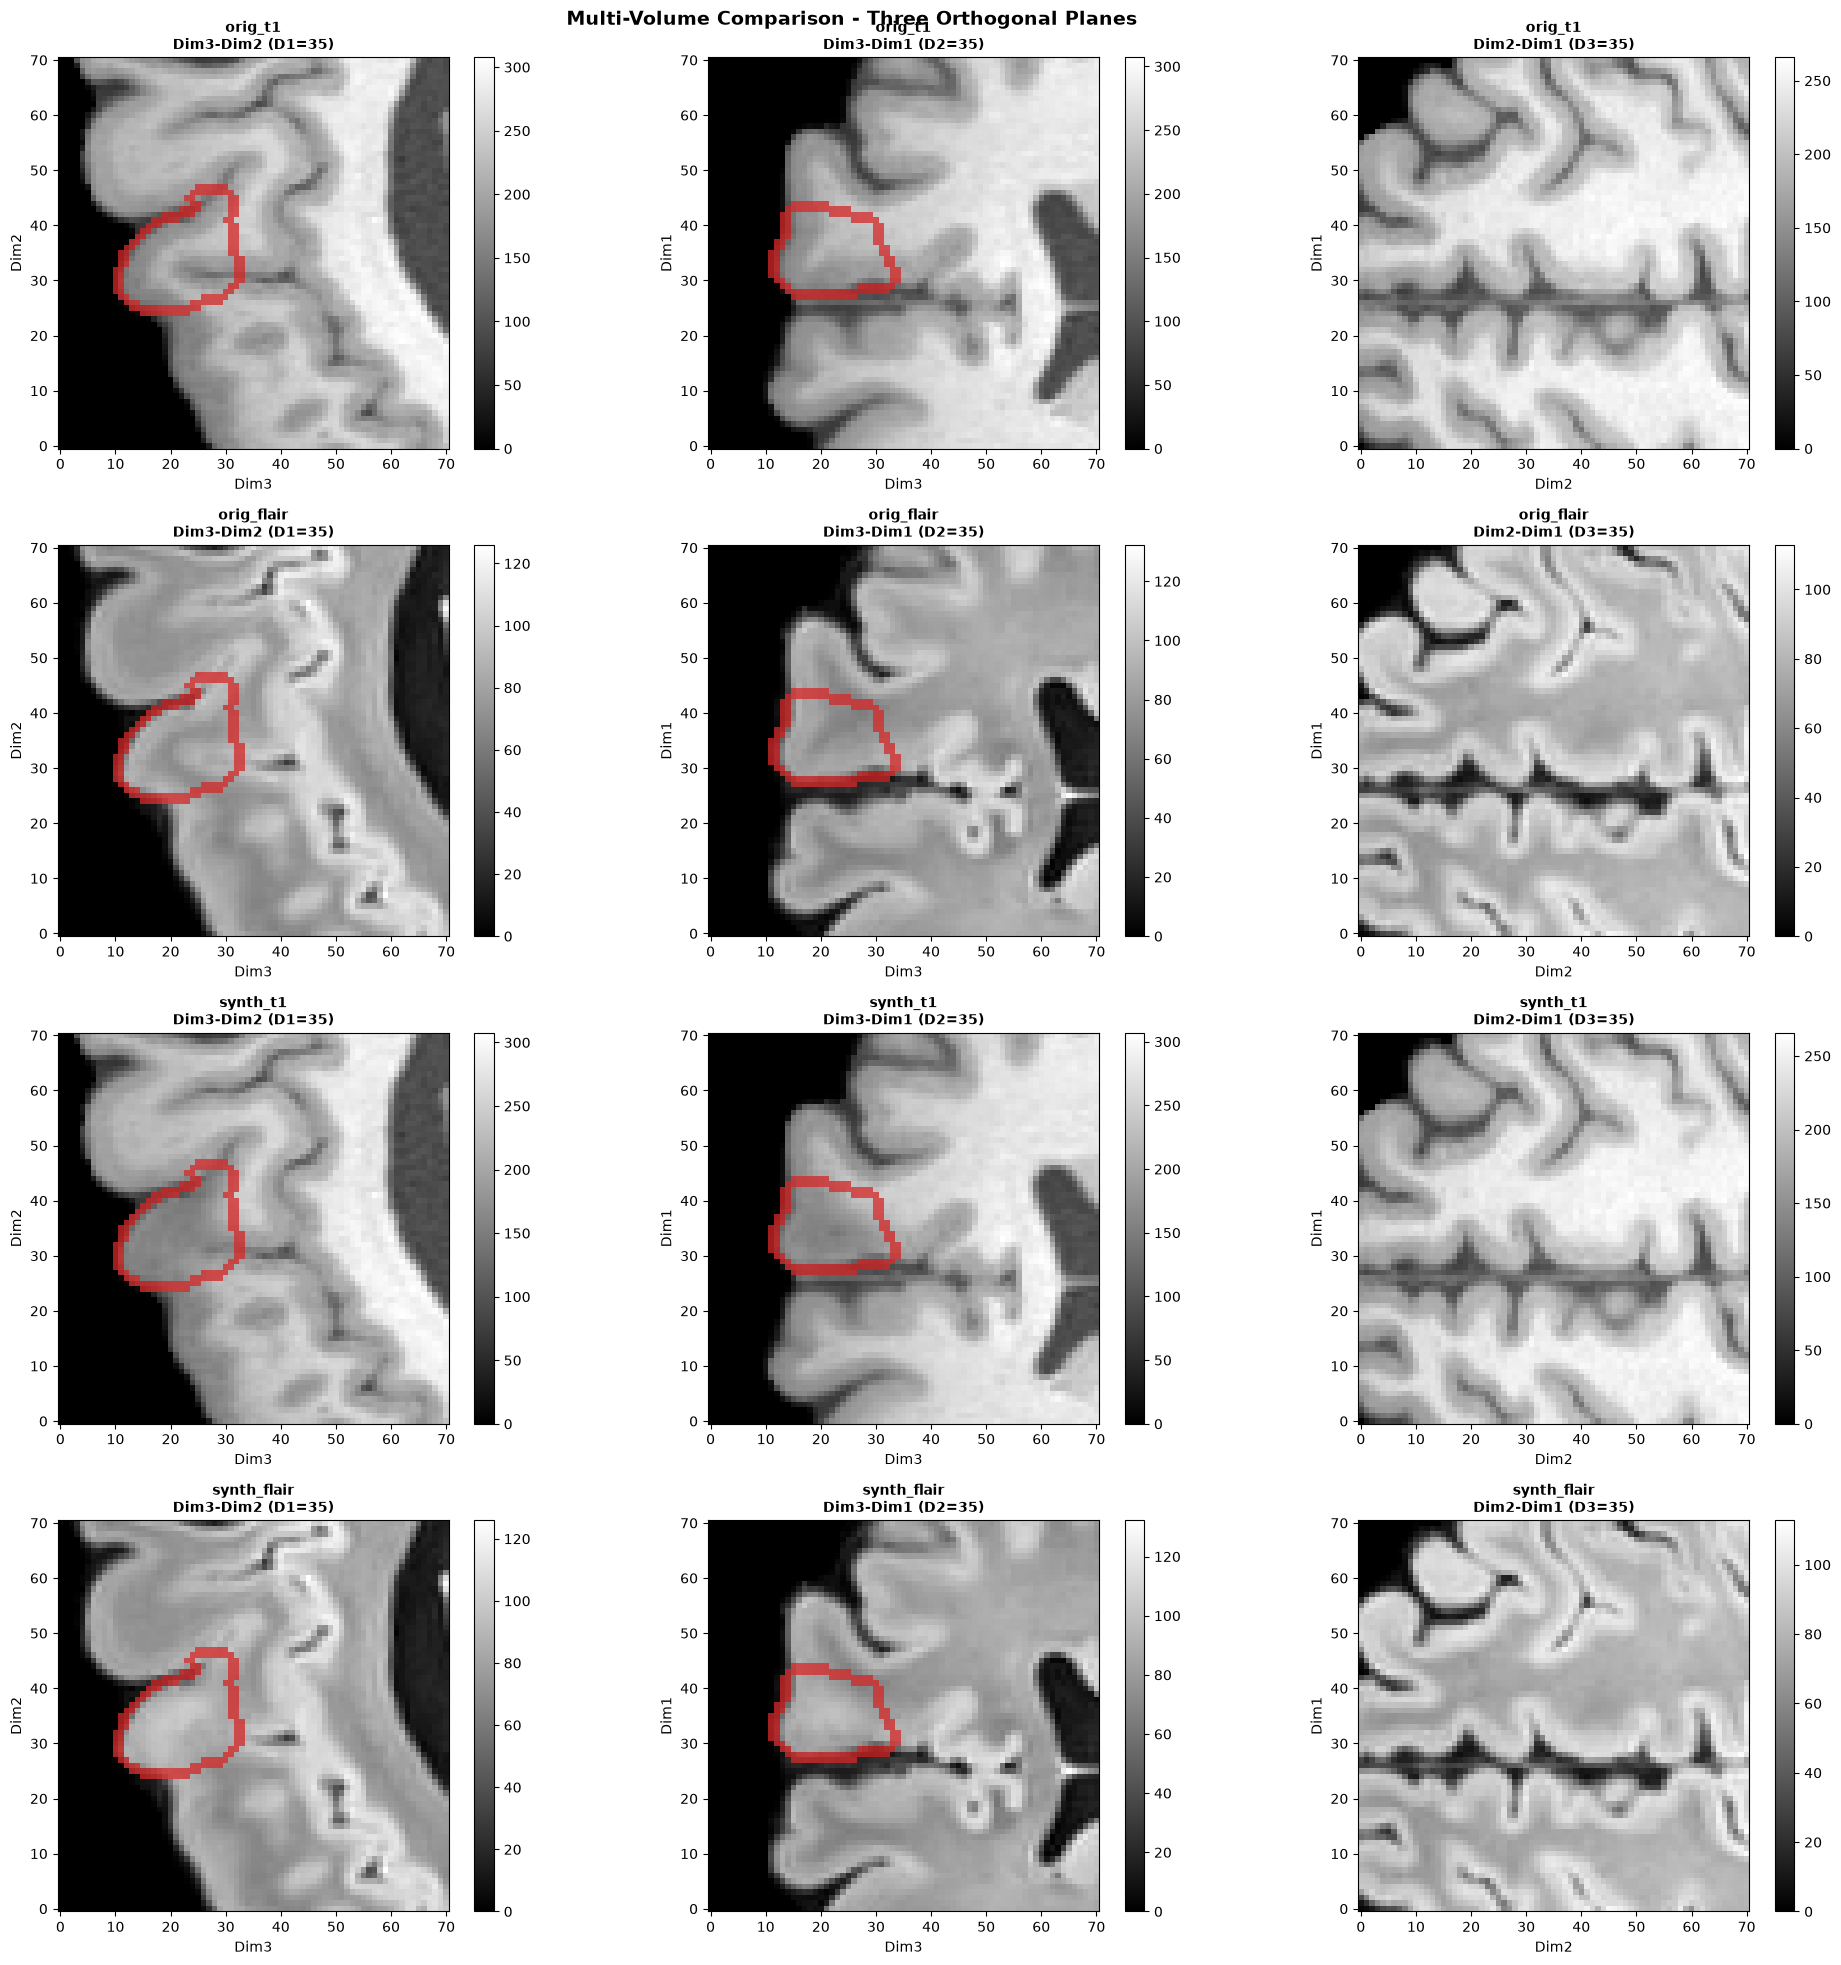

In [38]:
seed = running_rng.randint(0, 1000000)
print(f"Seed: {seed}")

out = load_and_simulate(
    t1_path=t1_path,
    flair_path=flair_path,
    seg_path=seg_path,
    presets="type_II_only",
    custom_params=None,
    show_params=True,
    random_seed=seed,
)

plot_bbox(
    out,
    pad_size=25,
    figsize=(20, 20),
    mask_dilation=2,
    ensure_square=True,
)

##### 4.2 Custom parametrization
##### 4.2.1 Type I-like

Seed: 794221
[Perf] Grow lesion: 1.407s | traced current=12.62 MB (+13,229,319 B) | traced peak=93.19 MB (+97,711,843 B)
[Perf] Apply local deformations: 0.236s | traced current=69.01 MB (+59,129,807 B) | traced peak=110.10 MB (+17,732,919 B)
[Perf] Apply local intensities: 0.252s | traced current=119.60 MB (+53,054,983 B) | traced peak=212.55 MB (+107,434,480 B)
[Perf] Pipeline total: 1.896s | traced current=119.60 MB | traced peak=212.55 MB
Growth statistics: {'volume': 591.0, 'hemisphere': 'right', 'DKT_labels': ['Right Entorhinal']}
[Perf] Grow lesion: 0.012s | traced current=8.41 MB (+8,817,618 B) | traced peak=8.41 MB (+8,818,530 B)
[Perf] Apply local deformations: 0.091s | traced current=46.25 MB (+39,676,681 B) | traced peak=87.34 MB (+82,761,333 B)
[Perf] Apply local intensities: 0.135s | traced current=46.39 MB (+151,899 B) | traced peak=156.16 MB (+72,165,808 B)
[Perf] Pipeline total: 0.239s | traced current=46.39 MB | traced peak=156.16 MB
Growth statistics: {'volume': 591.

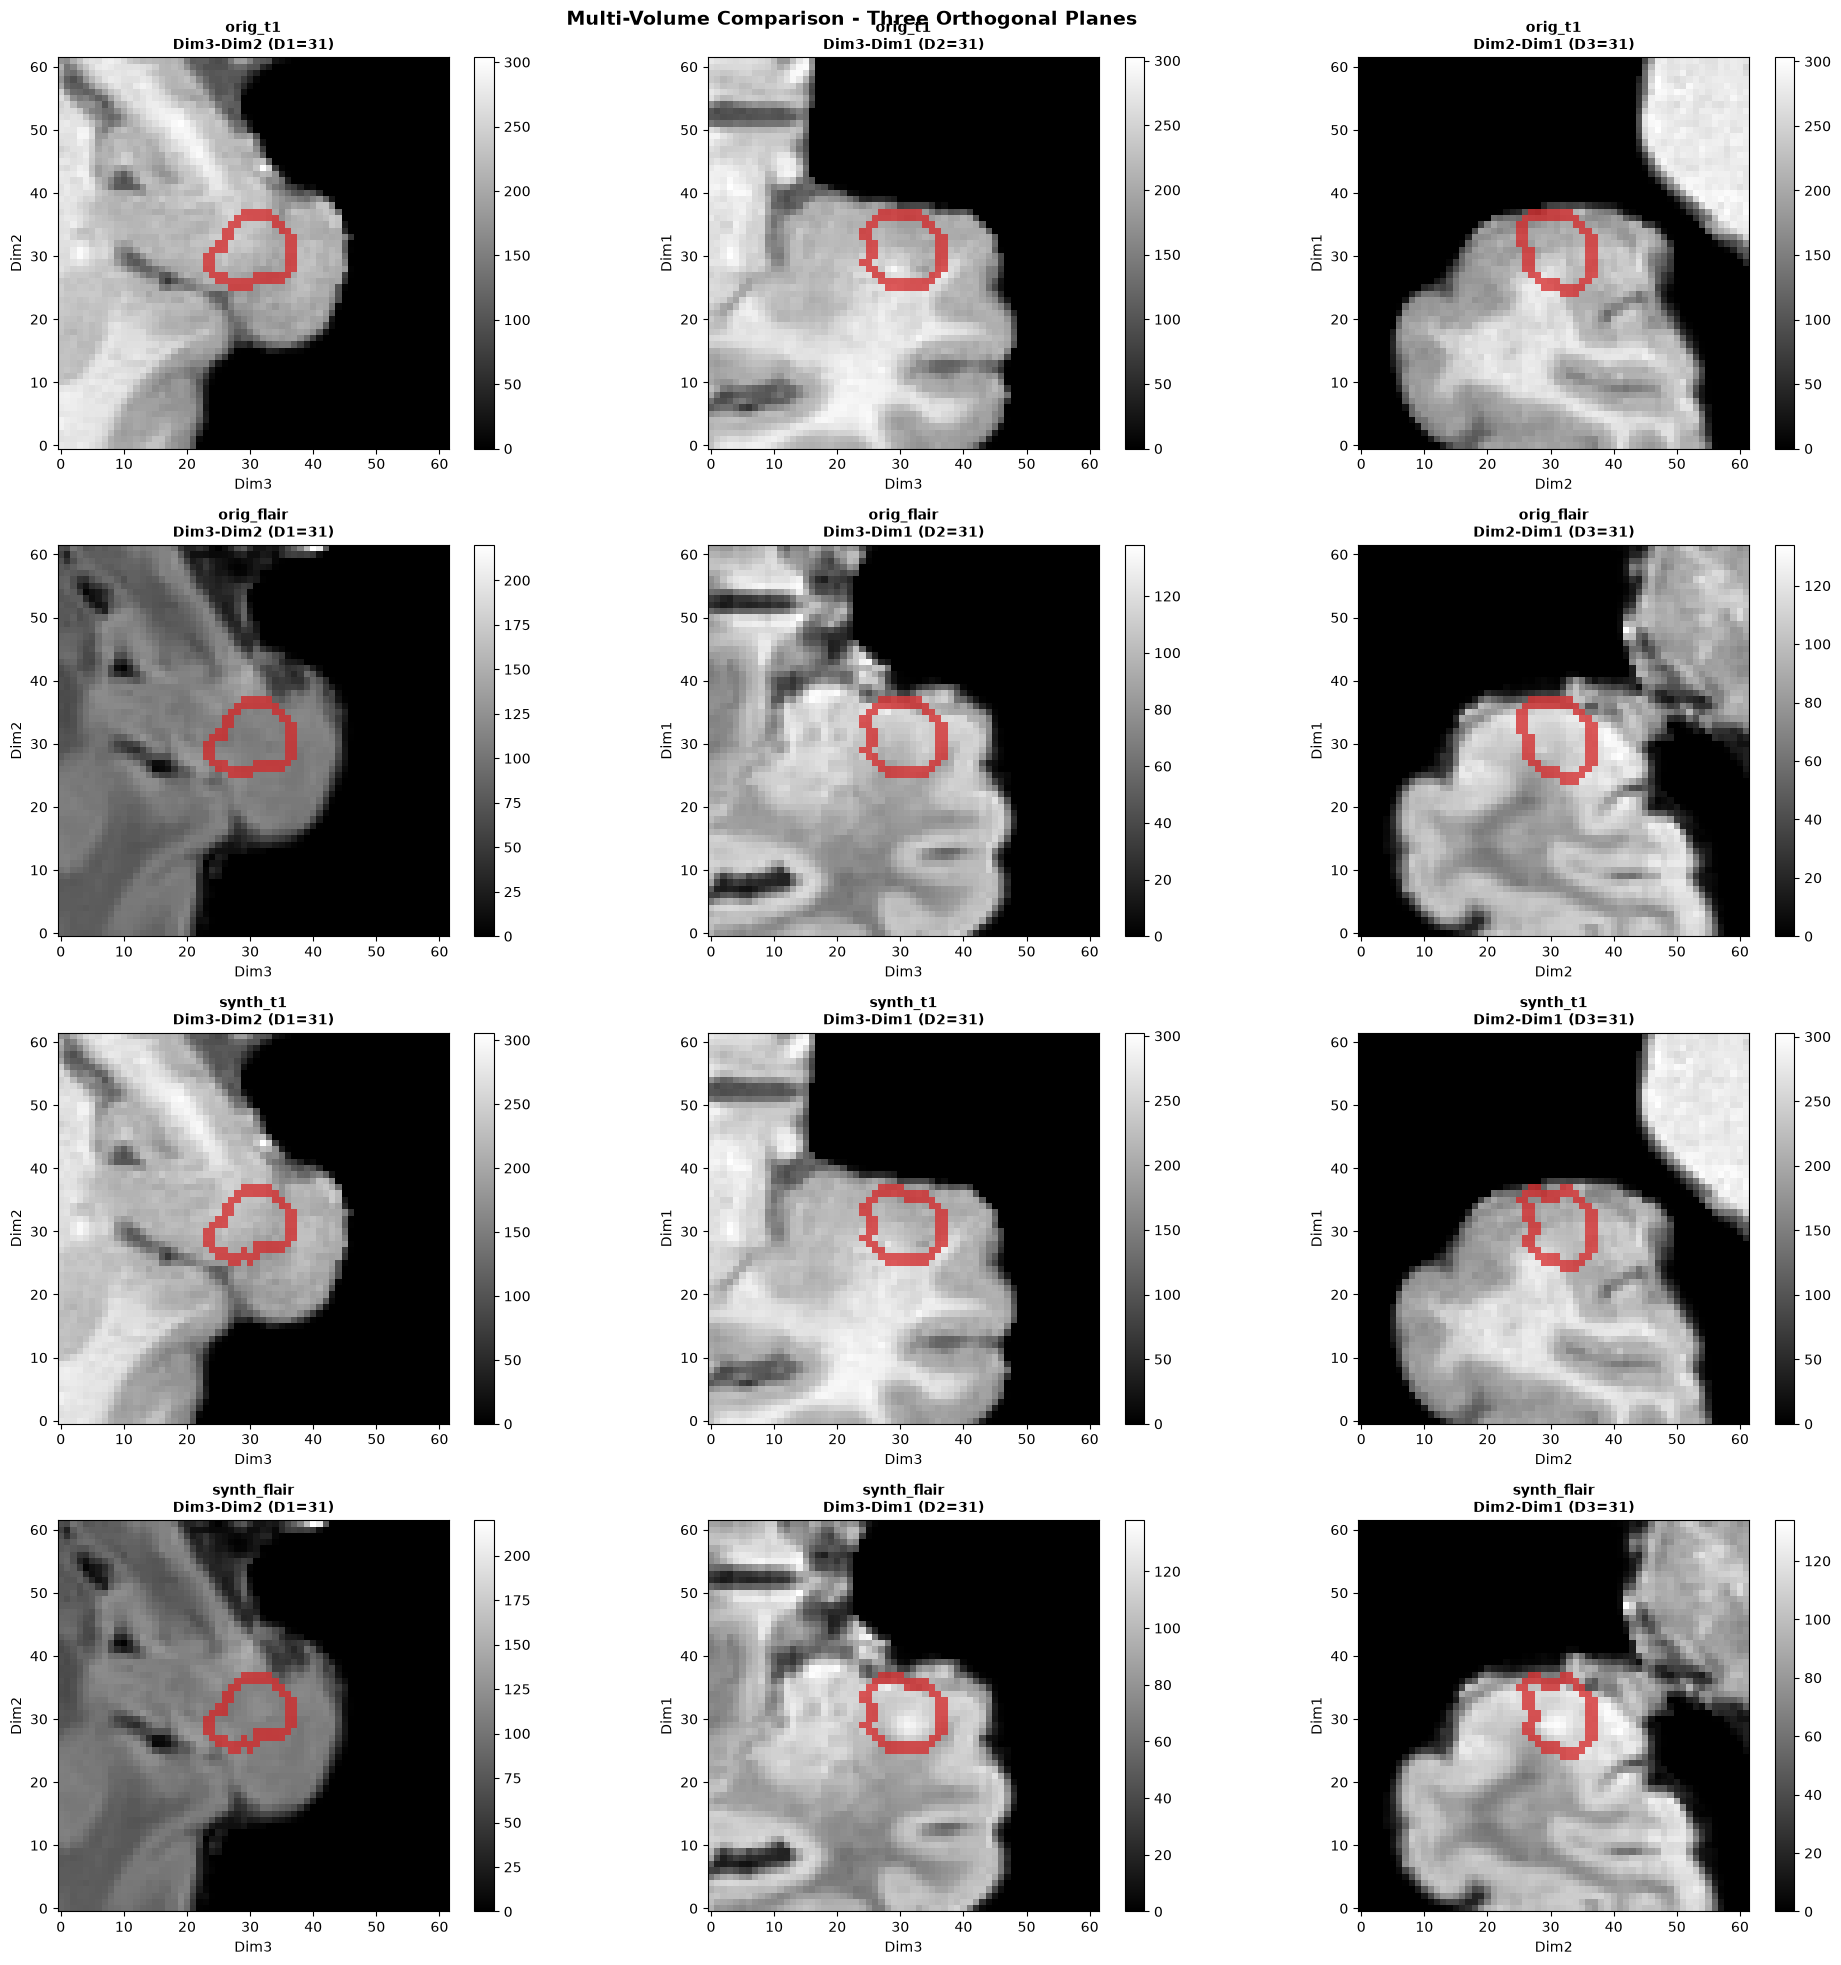

In [17]:
seed = running_rng.randint(0, 1000000)
print(f"Seed: {seed}")
rng = np.random.RandomState(seed)

intensity_params_base = {
    'boundary_blurring': {
        "enable": True,
        "n_iters": 20,
        "kappa": 0.95,
        "update_rate": 0.1,
        "pial_lower_bound": 2,
        "gwb_lower_bound": -1.0,
        "gwb_upper_bound": 2.0,
        "edge_rolloff": 1.0,
        "app_field_type": "outward",
        "app_rolloff": 2.0,
        "bbox_thres": 0.05,
    },
    'texture_restoration': {
        "enable": True,
        'hpf_img_sigma': 1.0,
        'corr_noise_sigma': 2.0,
        'hpf_noise_sigma': 3.0,
        'app_rolloff': 2.0,
        "app_field_type": "outward",
        "bbox_thres": 0.05,
        "noise_clip": 2.0,
        "random_seed": rng.randint(0, 1000000),
    },
    'hyperintensity': {
        "enable": True,
        "wmh_seeds_corr": 1.0,
        "wmh_seeds_hpf": 3.0,
        "gwb_prob_rolloff": 5.0,
        "start_prob": 0.9,
        "end_prob": 0.5,
        "scale_factor": 0.3,
        "n_iters": 20,
        "update_rate": 0.1,
        "kappa": 0.95,
        "gm_rolloff": 4.0,
        "edge_rolloff": 2.0,
        "app_field_type": "inward",
        "app_rolloff": 3.0,
        "bbox_thres": 0.01,
        "random_seed": rng.randint(0, 1000000),
    },
}
params = {
    "growth_params": {
        "volume": 600,
        "gm_prob": 0.9,
        "growth": "distance",
        "lobe": SynthSegLabel.get_temporal_lobe_labels(),
        "bottom_of_sulcus": False,
        "fast_mode": True,
        "distance_noise_ratio": 0.3,
        "random_seed": rng.randint(0, 1000000),
    },
    "deformation_params": {
        "abnormal_gyration": {
            "enable": False,
            "n_iters": 1,
            "mm_per_iter": 1.0,
            "pial_lower_bound": -3.0,
            "gwb_upper_bound": 3.0,
            "edge_rolloff": 1.0,
            "corr_sigma": 10,
            "smooth_sigma_field": 1.0,
            "scaling_and_squaring_steps": 5,
            "random_seed": rng.randint(0, 1000000),
            "app_field_type": "outward",
            "app_rolloff": 6.0,
            "bbox_thres": 0.01,
        },
        'cortical_thickening': {
            "enable": False,
            "n_iters": 1,
            "mm_per_iter": 1,
            "pial_lower_bound": 2.0,
            "gwb_upper_bound": 2,
            "edge_rolloff": 2.0,
            "smooth_sigma_field": 1,
            "app_field_type": "outward",
            "app_rolloff": 3.0,
            "bbox_thres": 0.01,
        },
        "sulcal_widening": {
            "enable": True,
            "n_iters": 1,
            "mm_per_iter": 1.1,
            "pial_lower_bound": -2,
            "pial_upper_bound": 2,
            "gwb_upper_bound": 0,
            "edge_rolloff": 1.0,
            "smooth_sigma_field": 1,
            "app_field_type": "outward",
            "app_rolloff": 10.0,
            "bbox_thres": 0.01,
        },
    },
    "intensity_params": [
        deepcopy(intensity_params_base),
        deepcopy(intensity_params_base),
    ],
}
params["intensity_params"][1]["texture_restoration"]["random_seed"] = rng.randint(0, 100000)
params["intensity_params"][0]["hyperintensity"]["scale_factor"] = (
    -0.1 * params["intensity_params"][1]["hyperintensity"]["scale_factor"]
)

out = load_and_simulate(
    t1_path,
    flair_path,
    seg_path,
    custom_params=params,
)

plot_bbox(
    out,
    pad_size=25,
    figsize=(20, 20),
    mask_dilation=2,
    ensure_square=True,
)

##### 4.2.2 Enlarged subarachnoid space

Seed: 908168
[Perf] Grow lesion: 1.297s | traced current=12.96 MB (+13,588,670 B) | traced peak=97.50 MB (+102,237,960 B)
[Perf] Apply local deformations: 0.342s | traced current=89.10 MB (+79,844,331 B) | traced peak=132.07 MB (+36,249,626 B)
[Perf] Apply local intensities: 0.175s | traced current=140.45 MB (+53,834,973 B) | traced peak=235.09 MB (+108,017,480 B)
[Perf] Pipeline total: 1.815s | traced current=140.45 MB | traced peak=235.09 MB
Growth statistics: {'volume': 2015.0, 'hemisphere': 'right', 'DKT_labels': ['Right Inferior Parietal', 'Right Superior Parietal']}
[Perf] Grow lesion: 0.004s | traced current=8.50 MB (+8,908,168 B) | traced peak=8.50 MB (+8,909,080 B)
[Perf] Apply local deformations: 0.089s | traced current=46.73 MB (+40,089,420 B) | traced peak=89.69 MB (+85,142,797 B)
[Perf] Apply local intensities: 0.110s | traced current=47.09 MB (+382,092 B) | traced peak=158.72 MB (+72,382,361 B)
[Perf] Pipeline total: 0.203s | traced current=47.09 MB | traced peak=158.72 M

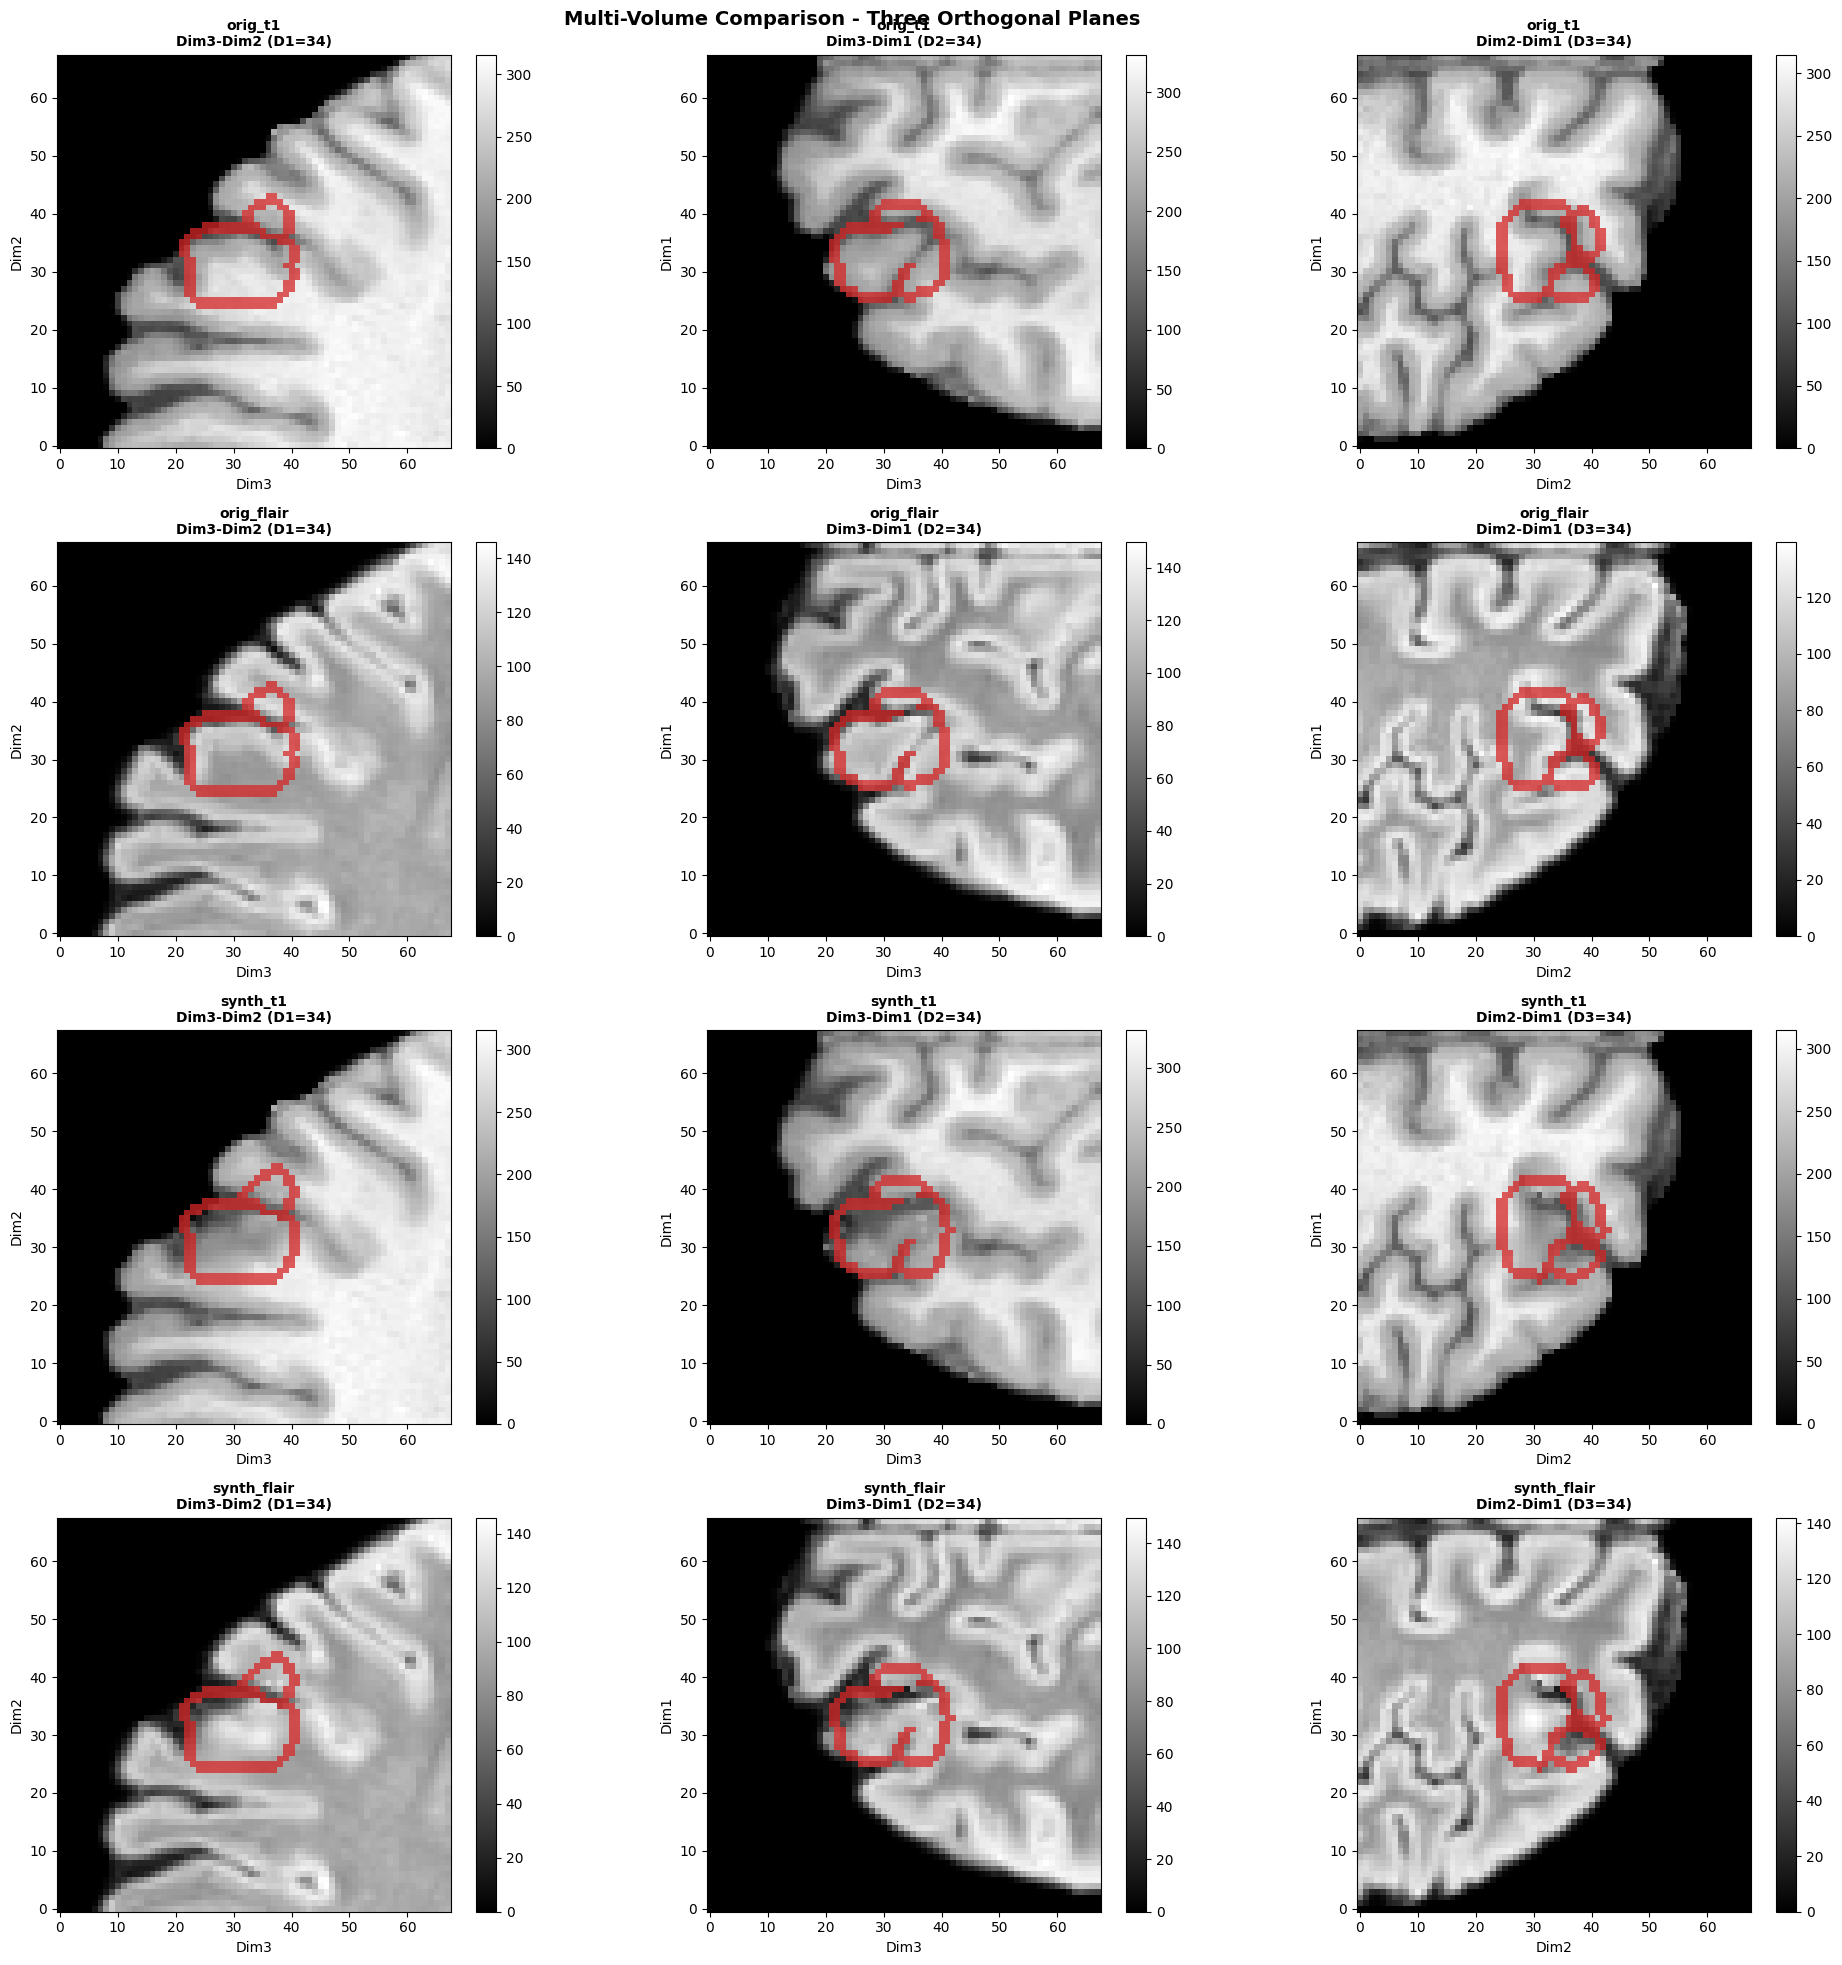

In [12]:
sub_id = "sub-00301"
data_dir = Path().resolve().parent.parent/"example_data"/"SASHIMI_examples"/f"{sub_id}"/"ses-01"/"anat"
t1_path = str(find_path_from_suffix("_T1w.nii.gz", data_dir))
flair_path = str(find_path_from_suffix("_FLAIR.nii.gz", data_dir))
seg_path = str(find_path_from_suffix("_synthseg.nii.gz", data_dir))

seed = running_rng.randint(0, 1000000)
seed = 908168
print(f"Seed: {seed}")
rng = np.random.RandomState(seed)

intensity_params_base = {
    'boundary_blurring': {
        "enable": True,
        "n_iters": 40,
        "kappa": 0.95,
        "update_rate": 0.1,
        "pial_lower_bound": 1.0,
        "gwb_lower_bound": -2.0,
        "gwb_upper_bound": 2.0,
        "edge_rolloff": 1.0,
        "app_field_type": "outward",
        "app_rolloff": 3.0,
        "bbox_thres": 0.05,
    },
    'texture_restoration': {
        "enable": True,
        'hpf_img_sigma': 1.0,
        'corr_noise_sigma': 1.0,
        'hpf_noise_sigma': 2.0,
        'app_rolloff': 3.0,
        "app_field_type": "outward",
        "bbox_thres": 0.05,
        "random_seed": rng.randint(0, 1000000),
    },
    'hyperintensity': {
        "enable": True,
        "wmh_seeds_corr": 1.0,
        "wmh_seeds_hpf": 3.0,
        "gwb_prob_rolloff": 8.0,
        "start_prob": 0.5,
        "end_prob": 0.2,
        "scale_factor": 0.4,
        "n_iters": 20,
        "update_rate": 0.1,
        "kappa": 0.95,
        "gm_rolloff": 2.0,
        "edge_rolloff": 1.0,
        "app_field_type": "inward",
        "app_rolloff": 3.0,
        "bbox_thres": 0.01,
        "random_seed": rng.randint(0, 1000000),
    },
}
params = {
    "growth_params": {
        "volume": 2000,
        "gm_prob": 0.7,
        "growth": "distance",
        "lobe": None,
        "bottom_of_sulcus": False,
        "fast_mode": True,
        "distance_noise_ratio": 0.3,
        "random_seed": rng.randint(0, 1000000),
    },
    "deformation_params": {
        "abnormal_gyration": {
            "enable": True,
            "n_iters": 2,
            "mm_per_iter": 2.0,
            "pial_lower_bound": -3.0,
            "gwb_upper_bound": 3.0,
            "edge_rolloff": 2.0,
            "corr_sigma": 5,
            "smooth_sigma_field": 1.0,
            "scaling_and_squaring_steps": 5,
            "random_seed": rng.randint(0, 1000000),
            "app_field_type": "outward",
            "app_rolloff": 6.0,
            "bbox_thres": 0.01,
        },
        'cortical_thickening': {
            "enable": True,
            "n_iters": 1,
            "mm_per_iter": 1,
            "pial_lower_bound": 2.0,
            "gwb_upper_bound": 2,
            "edge_rolloff": 2.0,
            "smooth_sigma_field": 1,
            "app_field_type": "outward",
            "app_rolloff": 3.0,
            "bbox_thres": 0.01,
        },
        "sulcal_widening": {
            "enable": False,
            "n_iters": 4,
            "mm_per_iter": 2.0,
            "pial_lower_bound": -2,
            "pial_upper_bound": 2,
            "gwb_upper_bound": 0,
            "edge_rolloff": 1.0,
            "smooth_sigma_field": 1,
            "app_field_type": "outward",
            "app_rolloff": 3.0,
            "bbox_thres": 0.01,
        },
    },
    "intensity_params": [
        deepcopy(intensity_params_base),
        deepcopy(intensity_params_base),
    ],
}
params["intensity_params"][1]["texture_restoration"]["random_seed"] = rng.randint(0, 1000000)
params["intensity_params"][0]["hyperintensity"]["scale_factor"] = (
    -0.35 * params["intensity_params"][1]["hyperintensity"]["scale_factor"]
)

out = load_and_simulate(
    t1_path,
    flair_path,
    seg_path,
    custom_params=params,
)

plot_bbox(
    out,
    pad_size=25,
    figsize=(20, 20),
    mask_dilation=2,
    ensure_square=True,
)

#### 5. Visualize effect fields
##### 5.1 Lesion growth and application field

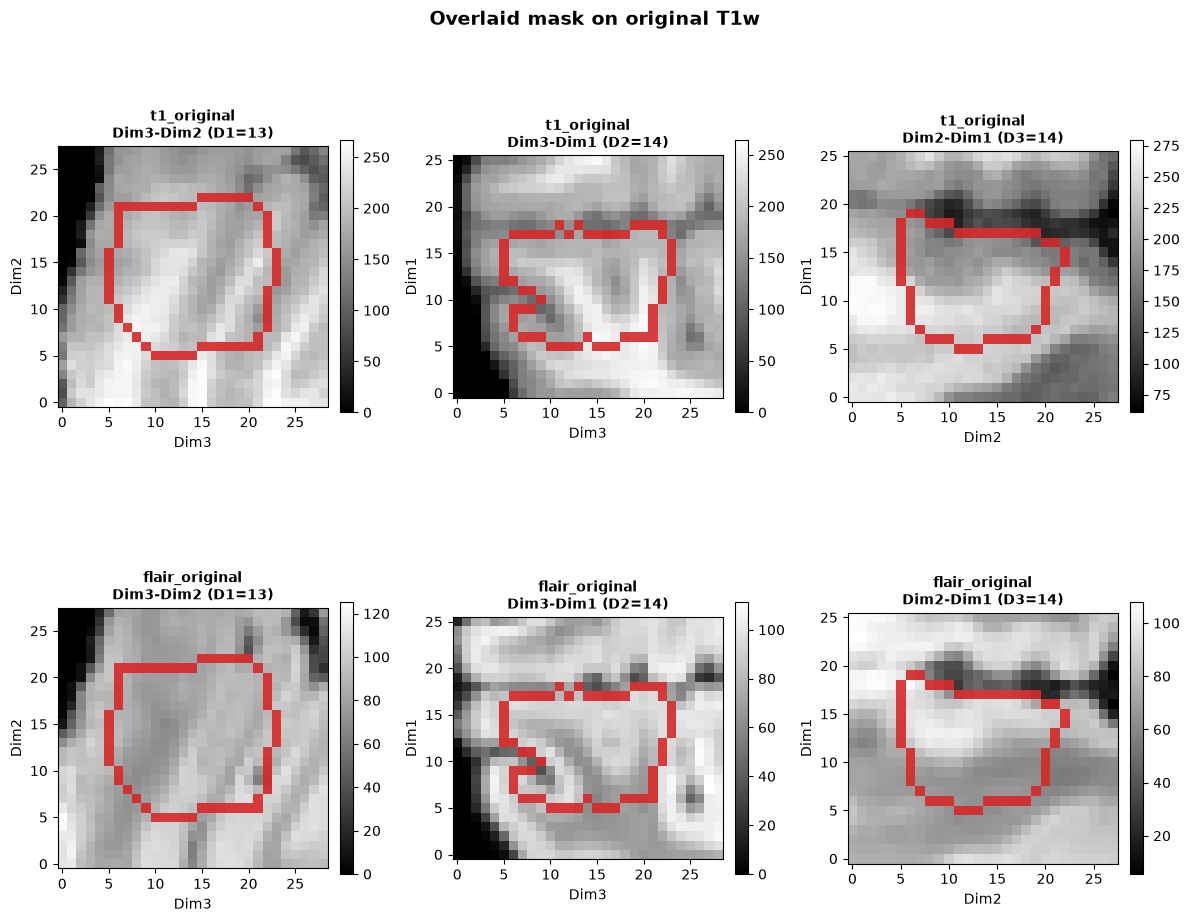

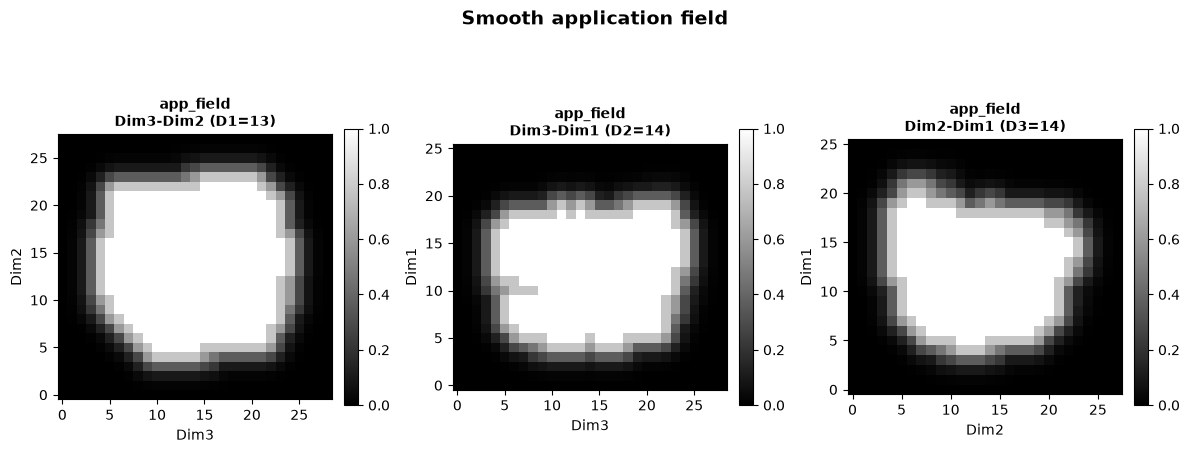

In [52]:
PAD_SIZE_GLOBAL = 25
PAD_SIZE_LOCAL = 5

# Growth lesion and display an application field
out_growth = grow_random_lesion(
    seg_mask=seg_mask_arr,
    spacing=spacing,
    volume=3000,
    gm_prob=0.75,
    growth="distance",
    lobe=SynthSegLabel.get_frontal_lobe_labels(),
    bottom_of_sulcus=False,
    fast_mode=True,
    random_seed=42,
    distance_noise_ratio=0.3
)
lesion_mask = out_growth["target"]
hemisphere = out_growth["growth_stats"]["hemisphere"]

# Get bounding box for locally applying the effects
bbox_local = bbox_from_mask(lesion_mask, pad=PAD_SIZE_LOCAL)

# Overlay lesion mask on original images
handles = plot_npy_volumes(
    {
        "t1_original": t1_arr[bbox_local],
        "flair_original": flair_arr[bbox_local]
    },
    title="Overlaid mask on original T1w",
    figsize=(12, 10),
    return_handles=True,
    show=False,
)
handles = overlay_mask_outline(
    handles,
    lesion_mask[bbox_local],
    rows=["t1_original", "flair_original"],
    color="tab:red",
)
show_plot_handles(handles)

# Display an application field
app_field = generate_application_field(
    lesion_mask,
    spacing=spacing,
    rolloff_mm=3.0,
)
plot_npy_volumes(
    {
        "app_field": app_field[bbox_local],
    },
    title="Smooth application field",
    figsize=(12, 5),
)

##### 5.2 Abnormal (stochastic) gyration

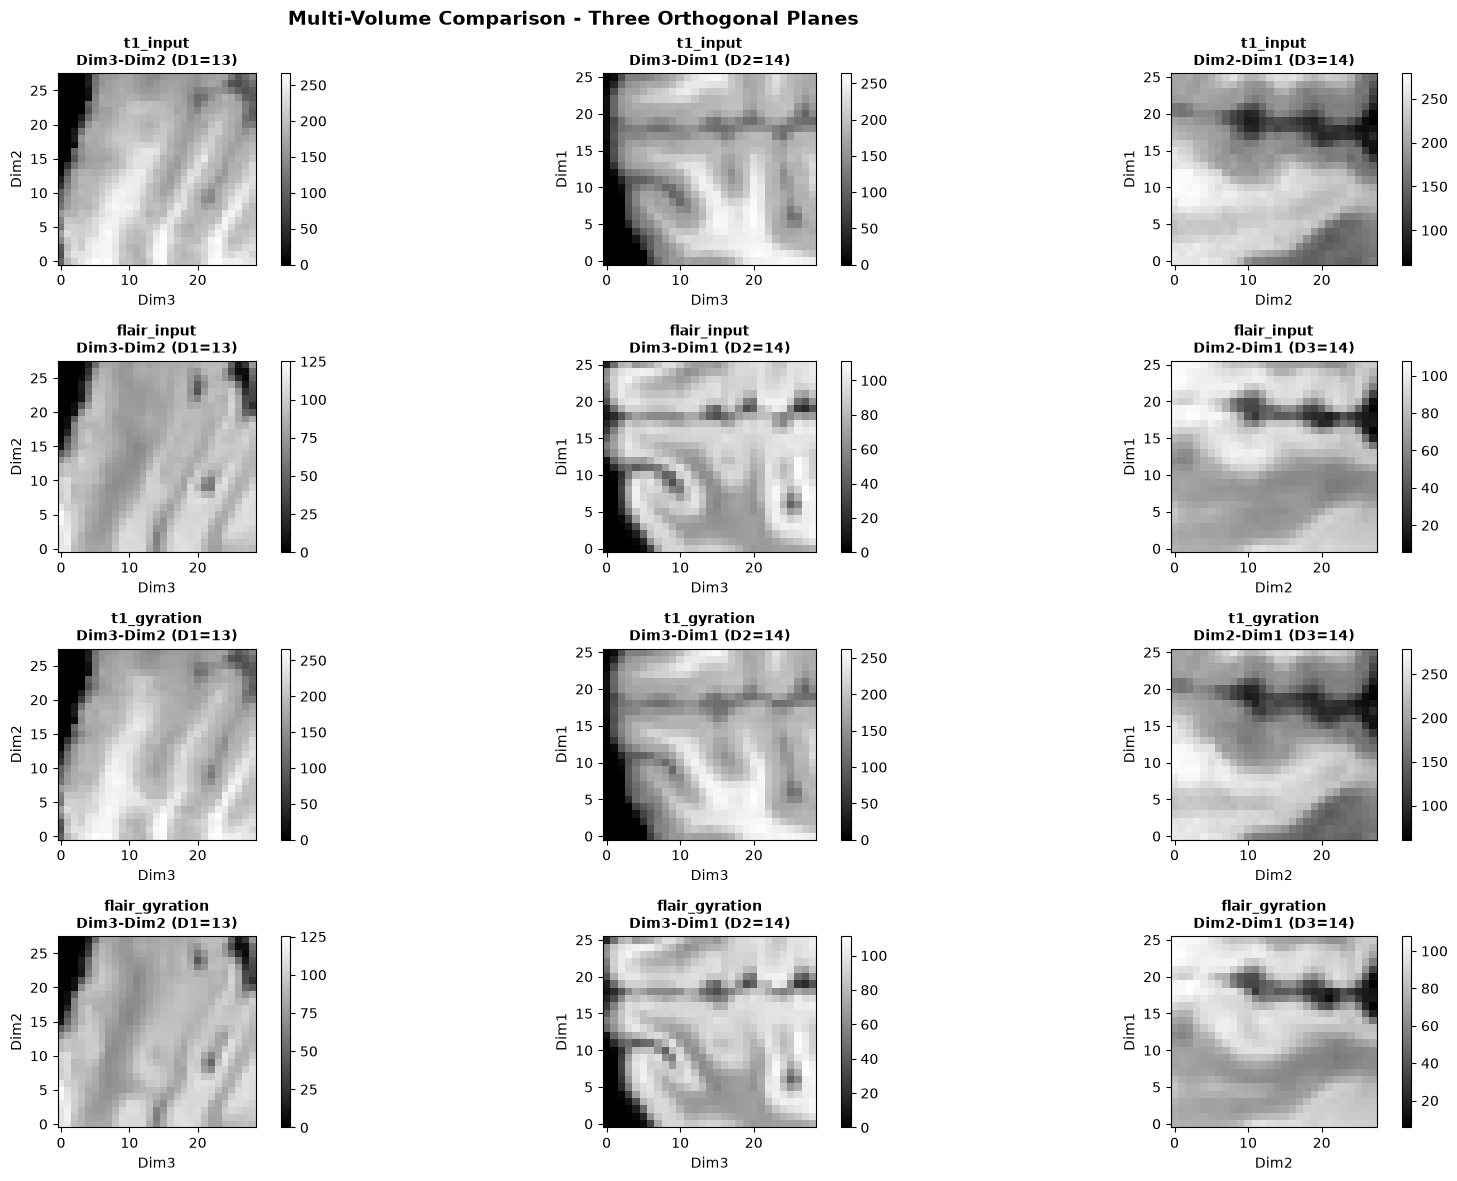

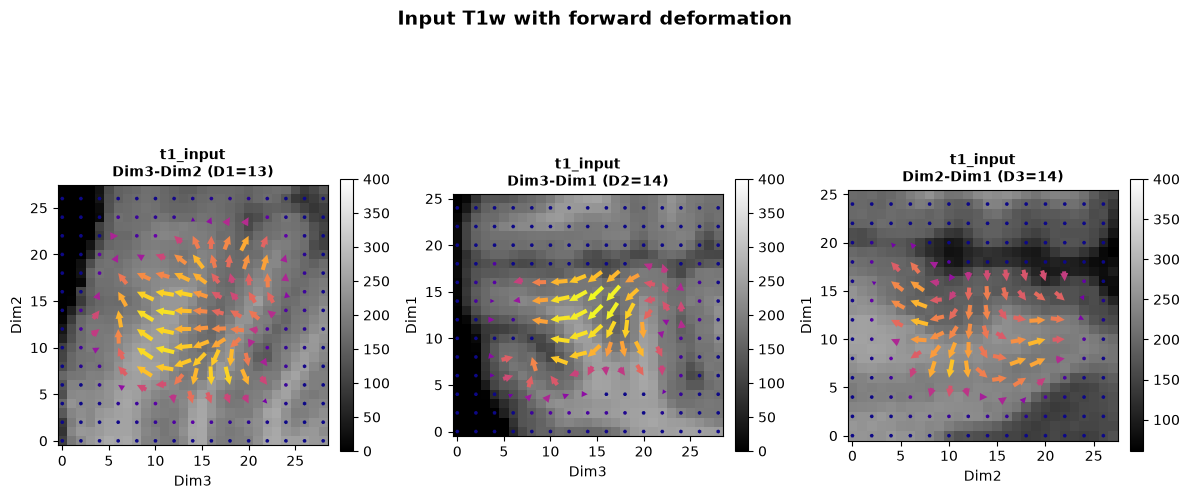

In [31]:
out_gyration = abnormal_gyration(
    image=t1_arr[bbox_local],
    seg_mask=seg_mask_arr[bbox_local],
    spacing=spacing,
    hemisphere=hemisphere,
    app_field=app_field[bbox_local],
    n_iters=1,
    mm_per_iter=1.5,
    pial_lower_bound=-2.0,
    gwb_upper_bound=3,
    corr_sigma=3.0,
    hpf_sigma=None,
    random_seed=12,
)

t1_arr_gyration = out_gyration['out_image']
seg_mask_arr_gyration = out_gyration["out_seg_mask"]
effect_field_gyration = out_gyration["effect_field"][0]  # first iter

# Warp lesion mask, application field, and flair
lesion_mask_gyration = warp(
    images = [lesion_mask[bbox_local]],
    deformation_fields=out_gyration['effect_field'],
    interp_order=0,
)[0]
app_field_gyration = warp(
    images = [app_field[bbox_local]],
    deformation_fields=out_gyration['effect_field'],
)[0]
flair_arr_gyration = warp(
    images = [flair_arr[bbox_local]],
    deformation_fields=out_gyration['effect_field'],
)[0]

# Display gyration images
plot_npy_volumes(
    {
        "t1_input": t1_arr[bbox_local],
        "flair_input": flair_arr[bbox_local],
        "t1_gyration": t1_arr_gyration,
        "flair_gyration": flair_arr_gyration
    }
)

# Overlay forward direction field on top of t1 (no need to show both)
handles = plot_npy_volumes(
    {
        "t1_input": t1_arr[bbox_local],
    },
    title="Input T1w with forward deformation",
    figsize=(12,6),
    return_handles=True,
    show=False,
    vmax=400,  # attenuate intensities (true max is ~270)
    #cmap='plasma',
)
# display as a forward field
overlay_vector_field_2d(
    handles,
    vector_field=(-effect_field_gyration[0], -effect_field_gyration[1], -effect_field_gyration[2]),
    stride=2,
    pivot="tip",
    arrow_scale=1.5,
    width=0.015,
    headwidth=2,
    headlength=2,
    headaxislength=2,
    color_from_magnitude=True,
    cmap_magnitude='plasma',
)
show_plot_handles(handles)


##### 5.2 Cortical thickening

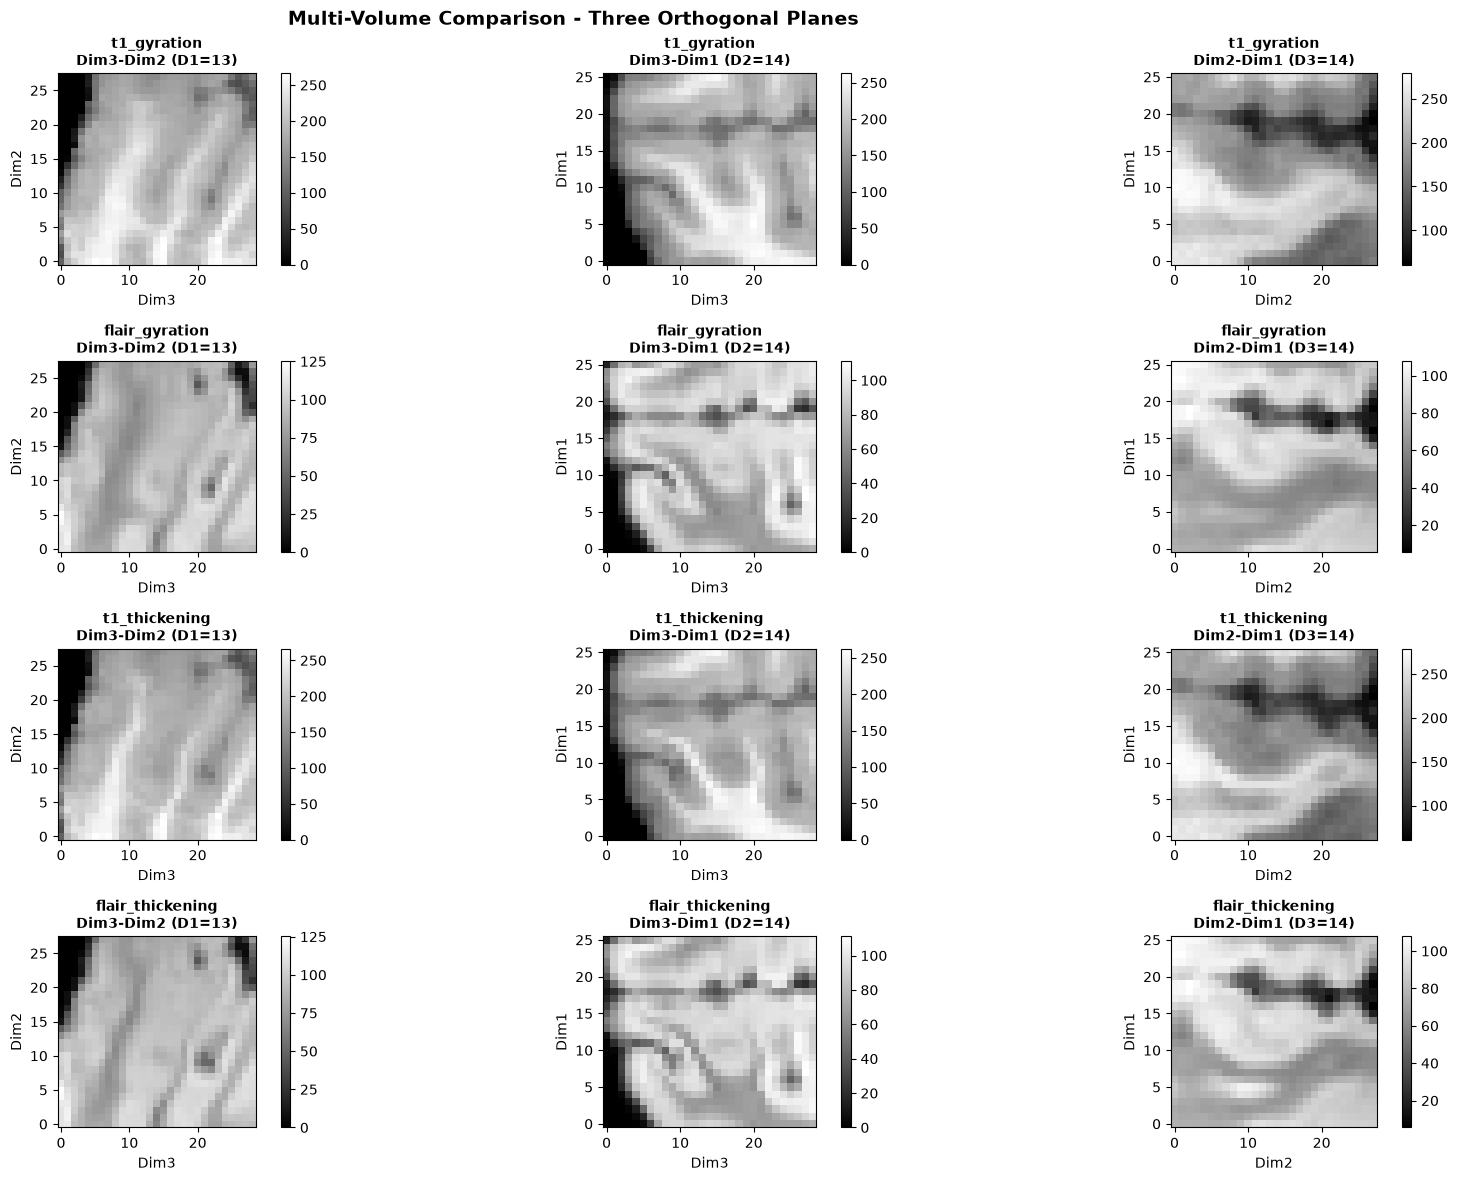

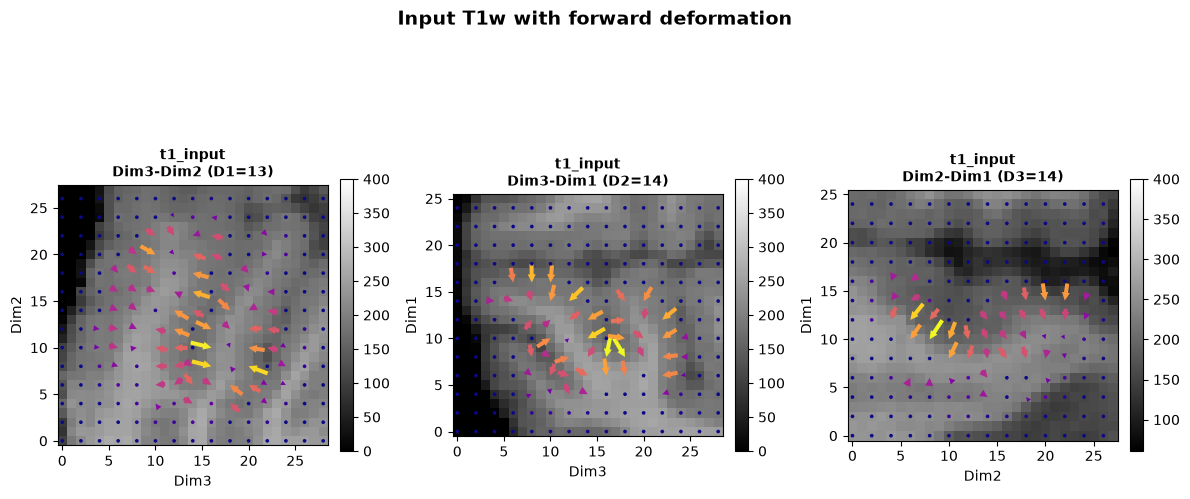

In [ ]:
out_thickening = cortical_thickening(
    image=t1_arr_gyration,
    seg_mask=seg_mask_arr_gyration,
    spacing=spacing,
    hemisphere=hemisphere,
    app_field=app_field_gyration,
    n_iters=1,
    mm_per_iter=1.5,
    pial_lower_bound=2.0,
    gwb_lower_bound=-2.0,  # useful when a tiny CSF is entirely missed by synthseg
    gwb_upper_bound=2,
)

t1_arr_thickening = out_thickening['out_image']
seg_mask_arr_thickening = out_thickening["out_seg_mask"]
effect_field_thickening = out_thickening["effect_field"][0]  # first iter

# Warp lesion mask, application field, and flair
lesion_mask_thickening = warp(
    images = [lesion_mask_gyration],
    deformation_fields=out_thickening['effect_field'],
    interp_order=0,
)[0]
app_field_thickening = warp(
    images = [app_field_gyration],
    deformation_fields=out_thickening['effect_field'],
)[0]
flair_arr_thickening = warp(
    images = [flair_arr_gyration],
    deformation_fields=out_thickening['effect_field'],
)[0]

# Display thickened images
plot_npy_volumes(
    {
        "t1_gyration": t1_arr_gyration,
        "flair_gyration": flair_arr_gyration,
        "t1_thickening": t1_arr_thickening,
        "flair_thickening": flair_arr_thickening
    }
)

# Overlay forward direction field on top of original images
handles = plot_npy_volumes(
    {
        "t1_input": t1_arr_gyration,
    },
    title="Input T1w with forward deformation",
    figsize=(12,6),
    return_handles=True,
    show=False,
    vmax=400,
)
overlay_vector_field_2d(
    handles,
    vector_field=(-effect_field_thickening[0], -effect_field_thickening[1], -effect_field_thickening[2]),
    stride=2,
    pivot="tip",
    arrow_scale=2.0,
    width=0.015,
    headwidth=2,
    headlength=2,
    headaxislength=2,
    color_from_magnitude=True,
    cmap_magnitude='plasma',
)
show_plot_handles(handles)


##### 5.3 GM-WM blurring

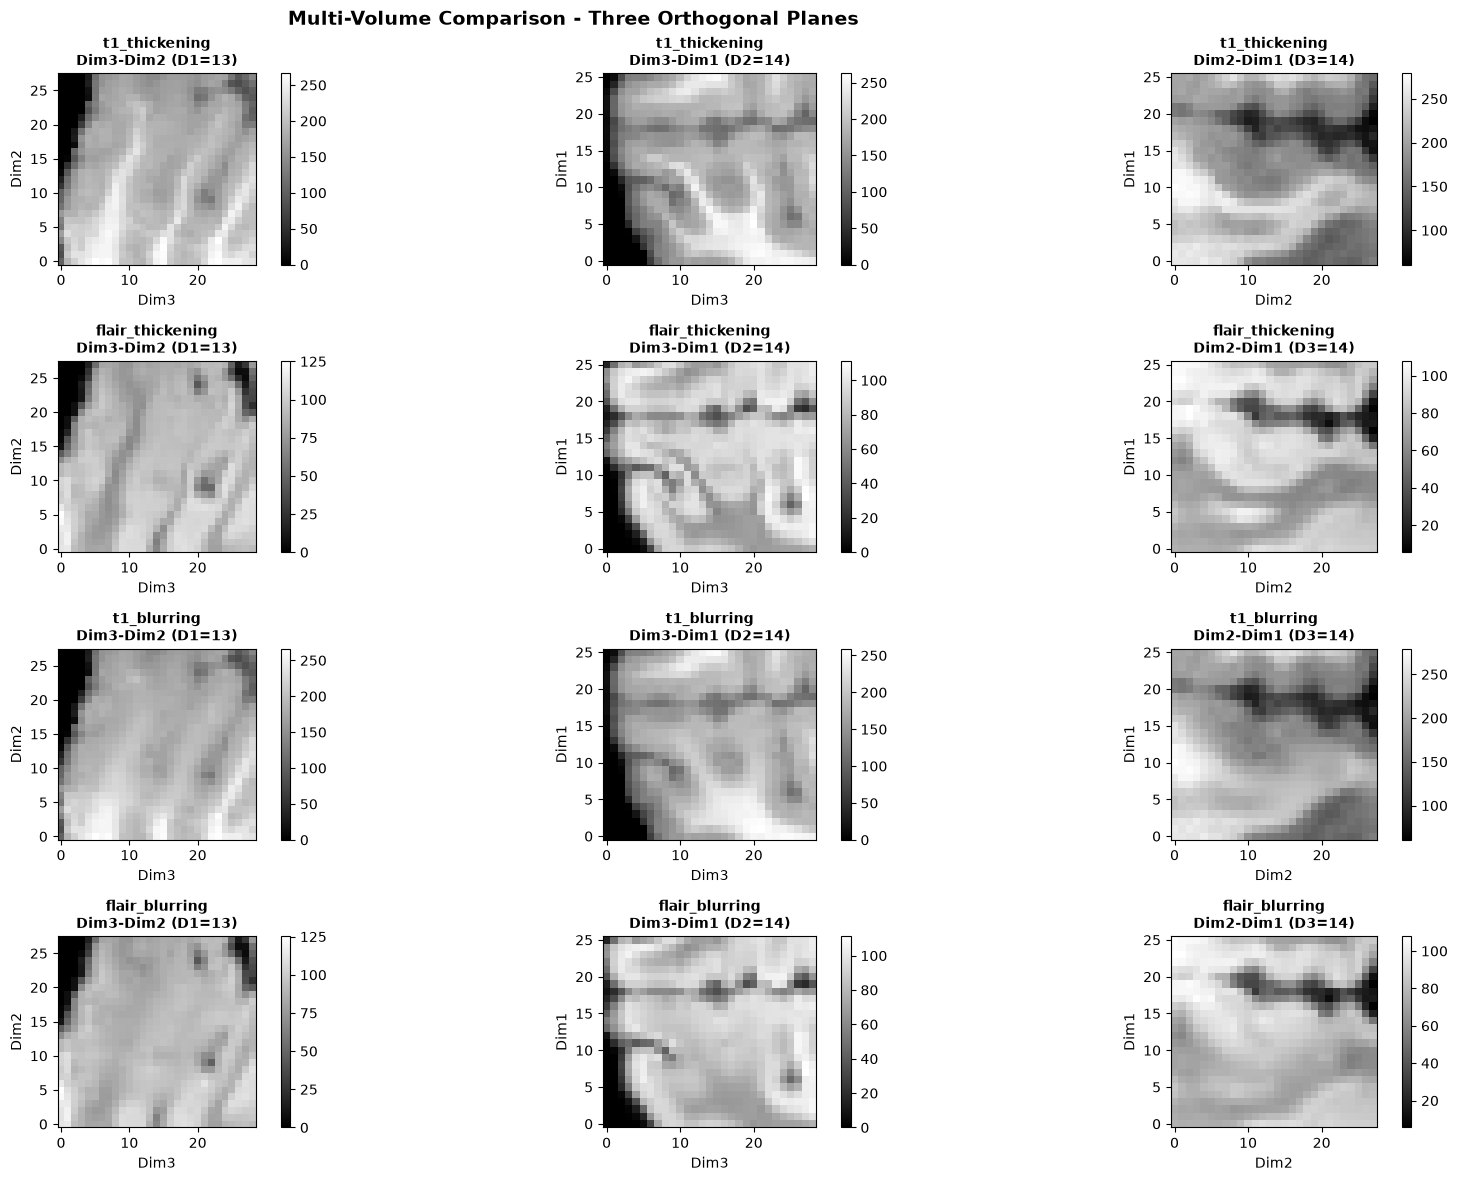

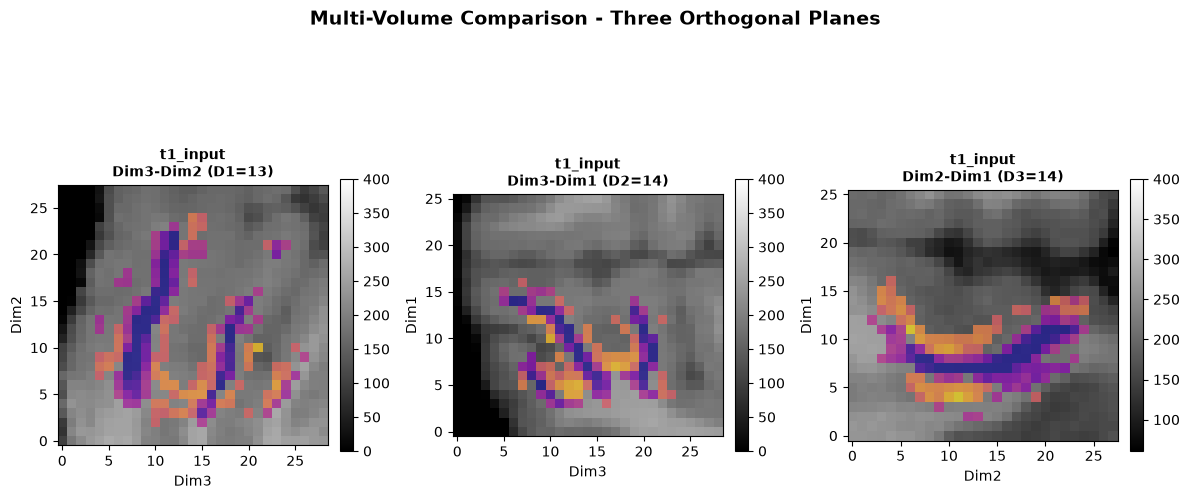

In [ ]:
out_blurring_t1 = boundary_blurring(
    image=t1_arr_thickening,
    seg_mask=seg_mask_arr_thickening,
    spacing=spacing,
    hemisphere=hemisphere,
    app_field=app_field_thickening,
    n_iters=10,
    pial_lower_bound=2,
    gwb_lower_bound=-2.0,
    gwb_upper_bound=3,
)

out_blurring_flair = boundary_blurring(
    image=flair_arr_thickening,
    seg_mask=seg_mask_arr_thickening,
    spacing=spacing,
    hemisphere=hemisphere,
    app_field=app_field_thickening,
    n_iters=10,
    pial_lower_bound=2,
    gwb_lower_bound=-2.5,
    gwb_upper_bound=3,
)


t1_arr_blurring = out_blurring_t1['out_image']
flair_arr_blurring = out_blurring_flair['out_image']
seg_mask_arr_blurring = seg_mask_arr_thickening
lesion_mask_blurring = lesion_mask_thickening
app_field_blurring = app_field_thickening
effect_field_blurring_t1 = out_blurring_t1["effect_field"]
effect_field_blurring_flair= out_blurring_flair["effect_field"]

# Also do restoration
out_texture_t1 = texture_restoration(
    image=t1_arr_blurring,
    seg_mask=seg_mask_arr_blurring,
    spacing=spacing,
    orig=t1_arr[bbox_local],
    hemisphere=hemisphere,
    app_field=generate_application_field(
        effect_field_blurring_t1 > 0.1,
        spacing=spacing,
        field_type="outward",
        rolloff_mm=2,
    ),
    hpf_img_sigma=1,
    corr_noise_sigma=0.8,
    hpf_noise_sigma=2.0,
    noise_clip=3,
    random_seed=14
)

out_texture_flair = texture_restoration(
    image=flair_arr_blurring,
    seg_mask=seg_mask_arr_blurring,
    spacing=spacing,
    orig=flair_arr[bbox_local],
    hemisphere=hemisphere,
    app_field=generate_application_field(
        effect_field_blurring_flair > 0.1,
        spacing=spacing,
        field_type="outward",
        rolloff_mm=2,
    ),
    hpf_img_sigma=1,
    corr_noise_sigma=0.8,
    hpf_noise_sigma=2.0,
    noise_clip=3,
    random_seed=22
)

t1_arr_blurring = out_texture_t1["out_image"]
flair_arr_blurring = out_texture_flair["out_image"]

# Display blurred images
plot_npy_volumes(
    {
        "t1_thickening": t1_arr_thickening,
        "flair_thickening": flair_arr_thickening,
        "t1_blurring": t1_arr_blurring,
        "flair_blurring": flair_arr_blurring
    },
)

# Overlay additive field on top of image
handles = plot_npy_volumes(
    {
        "t1_input": t1_arr_thickening,
    },
    figsize=(12,6),
    return_handles=True,
    show=False,
    vmax=400,
)
overlay_intensity_field(
    handles,
    field=effect_field_blurring_t1,
    mask=np.abs(effect_field_blurring_t1) > 3.6,  # arbitrary, for visualization
    alpha=0.75,
    cmap='plasma',
    vmin=-25,
    vmax=25,
)
show_plot_handles(handles)


##### 5.4 White matter hyperintensity

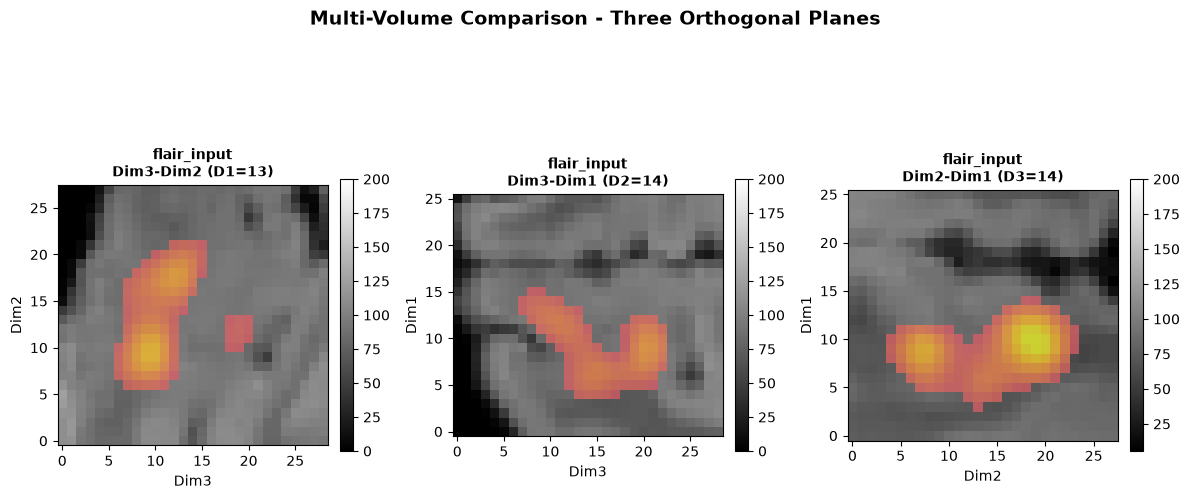

In [47]:
out_hyperintensity_t1 = hyperintensity(
    image=t1_arr_blurring,
    seg_mask=seg_mask_arr_blurring,
    spacing=spacing,
    app_field=app_field_blurring,
    wmh_seeds_corr=1,
    wmh_seeds_hpf=3,
    gwb_prob_rolloff=5,
    n_iters=20,
    scale_factor=-0.15,  # hypo-intense in T1w
    random_seed=13,
)

out_hyperintensity_flair = hyperintensity(
    image=flair_arr_blurring,
    seg_mask=seg_mask_arr_blurring,
    spacing=spacing,
    app_field=app_field_blurring,
    wmh_seeds_corr=1,
    wmh_seeds_hpf=3,
    gwb_prob_rolloff=5,
    n_iters=20,
    scale_factor=0.35,
    random_seed=13,
)

t1_arr_hypointensity = out_hyperintensity_t1['out_image']
flair_arr_hyperintensity = out_hyperintensity_flair['out_image']
seg_mask_arr_hyperintensity = seg_mask_arr_blurring
lesion_mask_hyperintensity = lesion_mask_blurring
app_field_hyperintensity = app_field_blurring
effect_field_hypointensity_t1 = out_hyperintensity_t1["effect_field"]
effect_field_hyperintensity_flair= out_hyperintensity_flair["effect_field"]

# Overlay hypperintensity field on top of FLAIR
handles = plot_npy_volumes(
    {
        "flair_input": flair_arr_blurring,
    },
    figsize=(12,6),
    return_handles=True,
    show=False,
    vmax=200,
)
overlay_intensity_field(
    handles,
    field=effect_field_hyperintensity_flair,
    mask=effect_field_hyperintensity_flair > 3.6,  # arbitrary, for visualization
    alpha=0.75,
    cmap='plasma',
    vmin=-25,
    vmax=25,
)
show_plot_handles(handles)

##### 5.5 Update global image

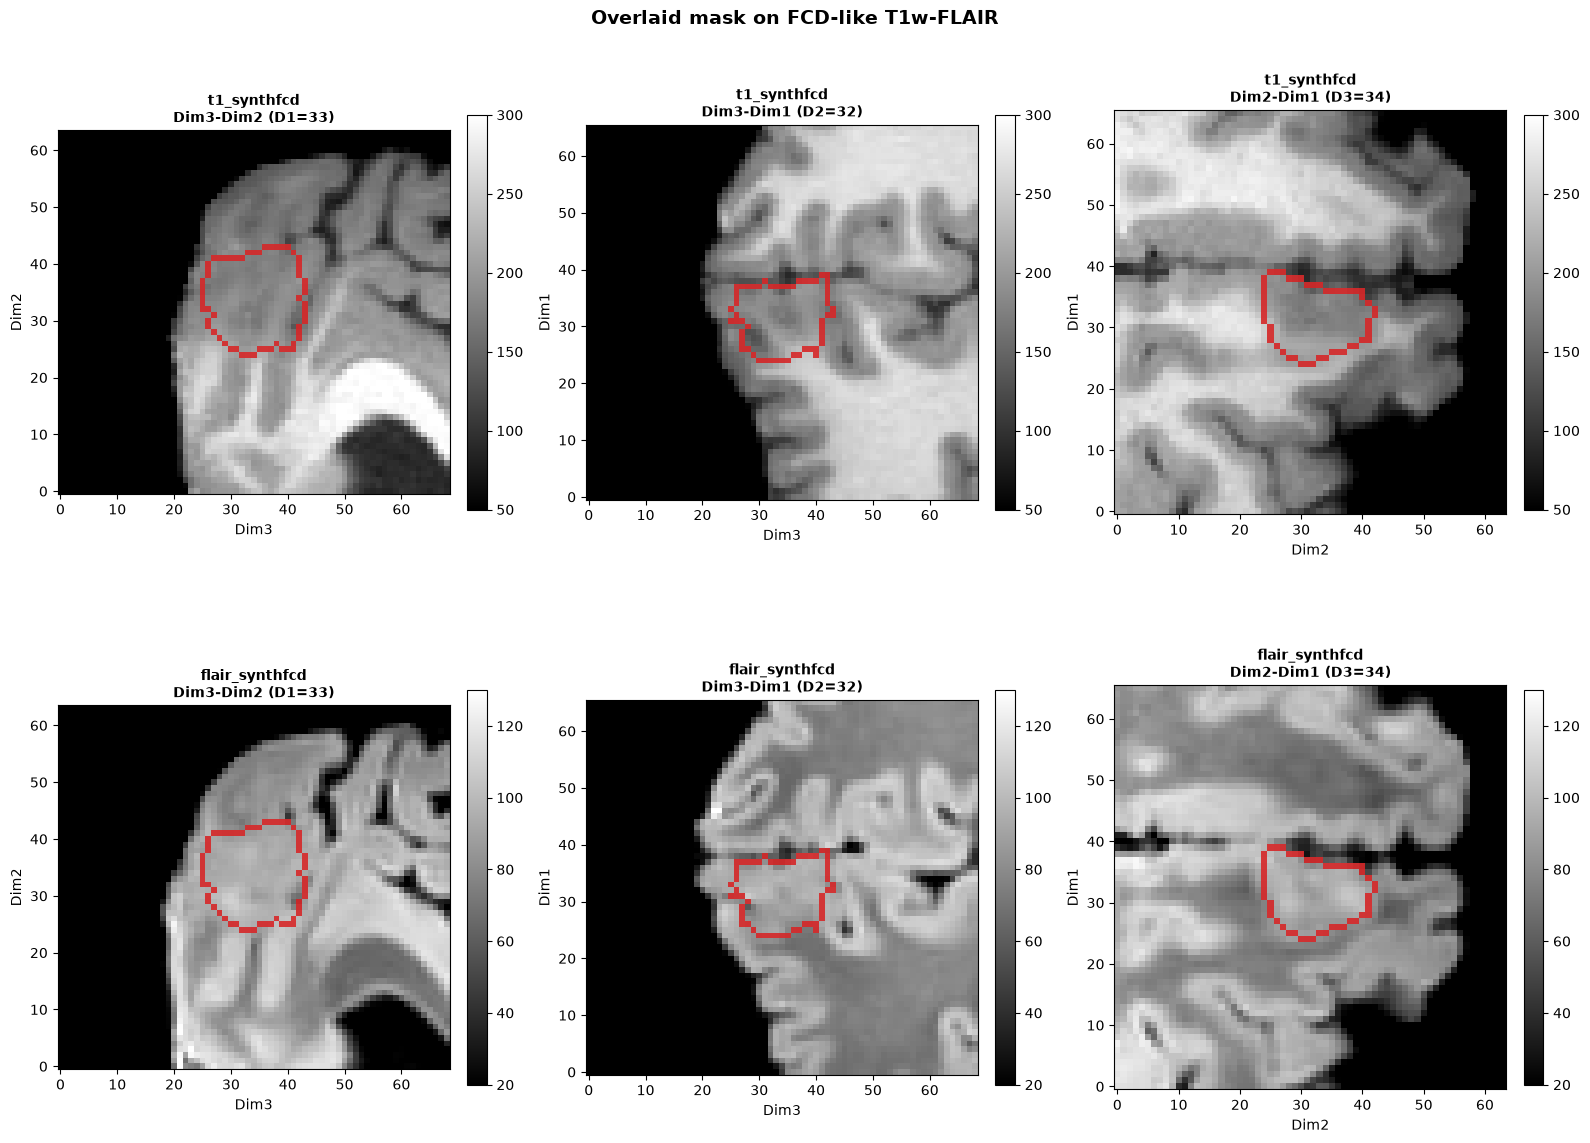

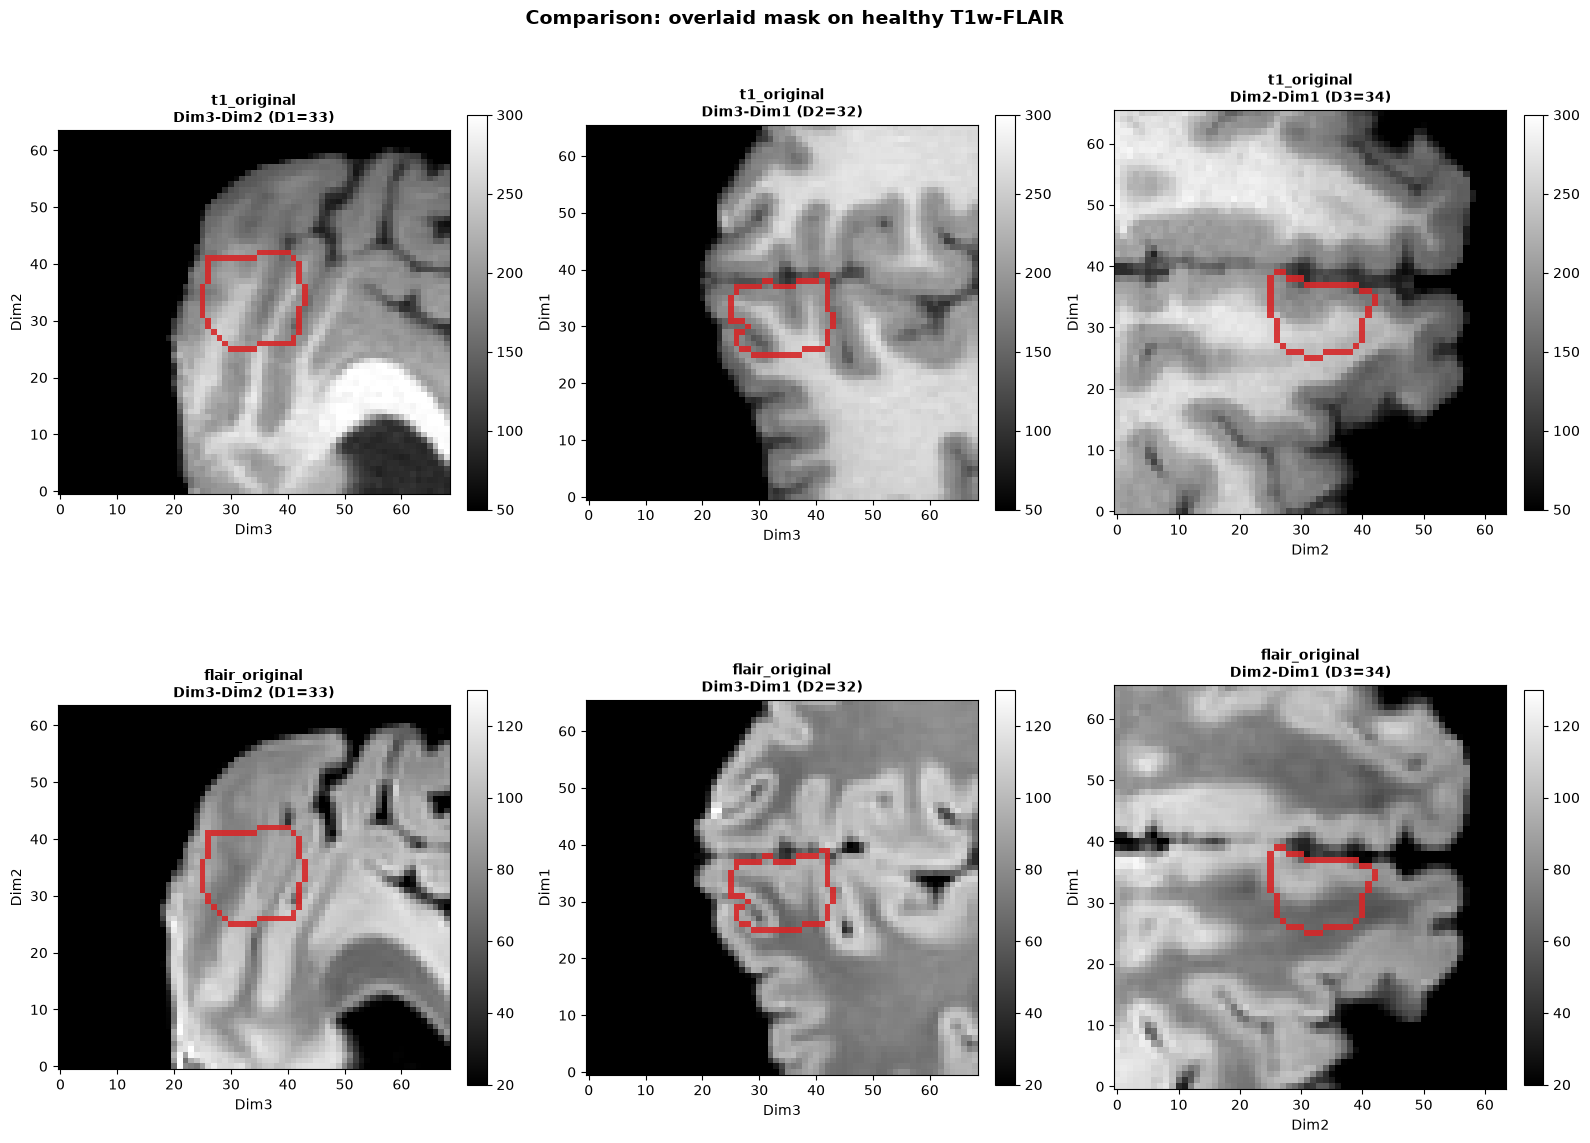

In [43]:
t1_arr_synthfcd = t1_arr.copy()
t1_arr_synthfcd[bbox_local] = t1_arr_hypointensity

flair_arr_synthfcd = flair_arr.copy()
flair_arr_synthfcd[bbox_local] = flair_arr_hyperintensity

lesion_mask_synthfcd = lesion_mask.copy()
lesion_mask_synthfcd[bbox_local] = lesion_mask_hyperintensity

# Overlay mask on FCD-like images-global
bbox_global = bbox_from_mask(lesion_mask, pad=PAD_SIZE_GLOBAL)
handles = plot_npy_volumes(
    {
        "t1_synthfcd": t1_arr_synthfcd[bbox_global],
        "flair_synthfcd": flair_arr_synthfcd[bbox_global]
    },
    title="Overlaid mask on FCD-like T1w-FLAIR",
    figsize=(16, 12),
    return_handles=True,
    show=False,
    vmin=[50, 20],
    vmax=[300, 130]
)
handles = overlay_mask_outline(
    handles,
    lesion_mask_synthfcd[bbox_global],
    rows=["t1_synthfcd", "flair_synthfcd"],
    color="tab:red",
)
show_plot_handles(handles)

# Overlay mask on original images-global
bbox_global = bbox_from_mask(lesion_mask, pad=PAD_SIZE_GLOBAL)
handles = plot_npy_volumes(
    {
        "t1_original": t1_arr[bbox_global],
        "flair_original": flair_arr[bbox_global]
    },
    title="Comparison: overlaid mask on healthy T1w-FLAIR",
    figsize=(16, 12),
    return_handles=True,
    show=False,
    vmin=[50, 20],
    vmax=[300, 130]
)
handles = overlay_mask_outline(
    handles,
    lesion_mask[bbox_global],
    rows=["t1_original", "flair_original"],
    color="tab:red",
)
show_plot_handles(handles)